<a href="https://colab.research.google.com/github/ThomasThread/NYC-Housing-Supply-Report-Automated-Data-Processor/blob/main/NYCHousingDatabaseAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## *Housing Production in New York City, 2010 - 2024*

The New York City Housing Database is a public data resource provided by the New York City Department of City Planning (DCP). The DCP compiles the dataset from a variety of Department of Finance, Department of Building, and other Department of City Planning data to provide a detail of all projects affecting housing units in New York City, with unique job numbers identifying each project. By pulling in the status of construction project paperwork for each job, a strong vision of the officially recognized housing stock change can be identified across time. Its worth noting that this dataset only views jobs that were in-progress or completing starting at the beginning of 2010, so all accounting of the change in housing stock provided by the dataset is best begun at that date.

The Housing Database is updated bi-annually, aligning to quarter 2 and quarter 4 of each year with a several month lag. There are two products provided: the Projects Database that lists jobs individually, and a Unit Change Summary that aggregates completions by year for geographies. In this project I will primarily use the Projects Database, bringing in the Unit Change Summary to introduce the census count of housing units in 2020.

This dataset is highly useful in identifying specific change in the housing stock over time, and I will demonstrate how I create a count of housing stock which allows for more detailed comparison to stated aims in housing production for both the city and for neighborhoods.

I have used this dataset extensively in my work at the Office of the State Comptroller of New York, producing a report titled "Housing Production in New York City" that was published in March of 2025 alongside my co-workers. It is available [here](https://www.osc.ny.gov/files/reports/pdf/report-24-2025.pdf). While I used Microsoft Excel to produce the report, this exploration within the Python coding language as well as the requirements to conduct hypothesis, and the necessity of compactness, will see this report containing different highlighted details with a core of the same ideas.


### *Data Cleaning*

The following is a rough progression of major steps taken:

1. Pull Primary Databases from NYC Open Data with a request.
2. Pare down the databases to the columns intended for use and rename column headers.
3. Include PUMA geographies in the project list and merge Unit Change Summary down to PUMA definitions as well.
4. Data type conversion.
5. Null Analysis and filters for bad data
6. Drop projects without a Net Class A change.

Old Notes:

First I will pull both the databases from the web to save space on my hard drive, and ease in transferring this file from computer to computer.
Then I pared down both databases to the columns I intended to use and renamed column headers as needed.
After that I checked and converted data types, especially in the projects database. I also made a note to ensure that any notation of housing unit change was an integer rather than decimalized, since there's not a measurement for part of a unit in this analysis.
Fourth I conducted a null analysis, using some information that I already knew about the database from previous analyses in Excel, namely that the CompltYear and PermitYear as well as DateComplt and DatePermit variables had expected nulls if a project had not reached that stage, so I had to both accommodate  those desirable  nulls as well as remove other null-value rows. Some checks like the review of the few nulls in PUMA found other data issues (depreciated BBLs) while removing ClassANet nulls removed the rest of the undesired null values.
Dropping projects without a net change in housing units was also conducted.

Below is the working process of this data cleaning:

In [ ]:
#Importing libararies for the project.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile
import io
import requests
import numpy as np
from IPython.display import Markdown
from google.colab import files
!pip install xlsxwriter
import xlsxwriter

pd.options.mode.chained_assignment = None # default='warn', which is used to suppress warnings that are not relevant to the analysis and work.

In [ ]:
#Setting some resetable parameters that will be used in the project, primarily to pull the correct data from OpenData and compare the right dates.
#NOTE: CHANGE DATES EVERY TIME
DBProjectDownloadPath = r"https://s-media.nyc.gov/agencies/dcp/assets/files/zip/data-tools/bytes/housing-project-level/nychdb_inactiveincluded_25q4_csv.zip"
DBUnitChangeDownloadPath = r"https://s-media.nyc.gov/agencies/dcp/assets/files/zip/data-tools/bytes/housing-unit-summary/nychousingdb_24q4_csv.zip" #Different vintage, but only using one column that is the same across vintages.
DBProjectsName = "HousingDB_post2010_inactive_included.csv"
DBUnitChangeNameCB = "HousingDB_by_2020_CensusBlock.csv"
DBUnitChangeNameNTA = "HousingDB_by_2020_NTA.csv"
PUMAtoCTPATH = r"https://usa.ipums.org/usa/resources/volii/2020_Census_Tract_to_2020_PUMA.csv"


In [ ]:
#Important version and date ranges to be set for each version
#Vintage
vintage = "2025_Q4"
#Change vintage_type based on the vintage
vintage_type = "Q4"
#vintage_type = "Q4"
#Year Name
year = 2025
# Define the start and end dates as strings
start_date_str = '2010-01-01'
end_date_str = '2025-12-31'


In [ ]:
#Importing the dataset from the zipped file instead of a downloaded local file. This reduces the number of actions I need to take to get the data I need.

#Requests allows me to check the status of the file on the server and download it if it is available.
response = requests.get(DBProjectDownloadPath)
if response.status_code == 200:
    # Extract the contents of the ZIP file with zipfile
    with zipfile.ZipFile(io.BytesIO(response.content), 'r') as z:
        # Extract the correct Excel file
        excel_file = DBProjectsName
        with z.open(excel_file) as ProjectsDB:
            # Read the dataset into a Pandas DataFrame
            prDB = pd.read_csv(ProjectsDB, low_memory=False)

#And the same for the Unit Change dataset.

response = requests.get(DBUnitChangeDownloadPath)
if response.status_code == 200:
    with zipfile.ZipFile(io.BytesIO(response.content), 'r') as z:
        excel_file = DBUnitChangeNameCB
        with z.open(excel_file) as UnitChangeDB:
            UnitChangeCB = pd.read_csv(UnitChangeDB, low_memory=False) #Unit Change by Census Block

response = requests.get(DBUnitChangeDownloadPath)
if response.status_code == 200:
    with zipfile.ZipFile(io.BytesIO(response.content), 'r') as z:
        excel_file = DBUnitChangeNameNTA
        with z.open(excel_file) as UnitChangeNTA:
            UnitChangeNTA = pd.read_csv(UnitChangeNTA, low_memory=False) #Unit Change by Census Block

#And the again for the PUMA to Census Tract Crosswalk.

response = requests.get(PUMAtoCTPATH)
if response.status_code == 200:
          PUMAtoCT = pd.read_csv(PUMAtoCTPATH, low_memory=False)

In [ ]:
if vintage_type == "Q4":
    # Extract the year from the vintage string (e.g., "2025_Q4" -> 2025)
    vintage_year = int(vintage.split('_')[0])

    # Filter prDB to keep only entries where 'CompltYear' is less than or equal to the vintage year
    # Handle potential NaN values in 'CompltYear' by ensuring they are not dropped if they meet other criteria, but here we explicitly compare.
    prDB = prDB[prDB['CompltYear'].fillna(vintage_year) <= vintage_year]

In [ ]:
#Now PUMAtoCT needs to be set up to match the cenblock style ('state#','0','county#')

#convert PUMAtoCT into a FIPS code for Census Tract
#Pad the state, county, and tract columns with leading zeros
PUMAtoCT['STATEFP'] = PUMAtoCT['STATEFP'].astype(str).str.zfill(2)
PUMAtoCT['COUNTYFP'] = PUMAtoCT['COUNTYFP'].astype(str).str.zfill(3)
PUMAtoCT['TRACTCE'] = PUMAtoCT['TRACTCE'].astype(str).str.zfill(6)

# Concatenate the columns to create the FIPS code
PUMAtoCT['centract20'] = PUMAtoCT['STATEFP'] + PUMAtoCT['COUNTYFP'] + PUMAtoCT['TRACTCE']

#Filter PUMAtoCT for only STATEFP = 36
PUMAtoCT = PUMAtoCT[PUMAtoCT['STATEFP'] == '36']

#Grab only the PUMA5CE and centract20 columns
PUMAtoCT = PUMAtoCT[['PUMA5CE', 'centract20']]

#Rename the PUMA5CE column to PUMA
PUMAtoCT = PUMAtoCT.rename(columns={'PUMA5CE': 'PUMA'})

# Display the updated DataFrame with the new FIPS column
print(PUMAtoCT.head(5))
print(PUMAtoCT.dtypes)

       PUMA   centract20
49732  2001  36001000100
49733  2001  36001000201
49734  2001  36001000202
49735  2001  36001000301
49736  2001  36001000302
PUMA           int64
centract20    object
dtype: object


In [ ]:
#UnitChangeCB needs to be summarized into Census Tracts, without loss of data columns.
#Create a new column based on cenblock20 to a FIPS code for Census Tracts (Use Gemini)
UnitChangeCB['cenblock20'] = UnitChangeCB['cenblock20'].astype(str) # Ensure the column is string type
UnitChangeCB['centract20'] = UnitChangeCB['cenblock20'].str[:-4]

#Now summarize by addition all columns in UnitChangeCB by the centract20 column, name it UnitChangeCT
UnitChangeCT = UnitChangeCB.groupby('centract20').sum()
#remove the deprecated bctcb2020 and cenblock20 columns
UnitChangeCT = UnitChangeCT.drop(columns=['bctcb2020', 'cenblock20'])

#Check the head to see if this worked.
print(UnitChangeCT.head(5))


             comp2020ap  comp2010  comp2011  comp2012  comp2013  comp2014  \
centract20                                                                  
36005000100           0         0         0         0         0         0   
36005000200           0        21         0         2         0         0   
36005000400           0       119        10         1        -1        -1   
36005001600          -1         0         6         0         0         0   
36005001901          22       213       221        60         0         4   

             comp2015  comp2016  comp2017  comp2018  ...  comp2021  comp2022  \
centract20                                           ...                       
36005000100         0         0         0         0  ...         0         0   
36005000200         0         0        -2         0  ...         4         0   
36005000400        46        58        35         0  ...         5         1   
36005001600         0         1         0         0  ...    

In [ ]:
#Append PUMAtoCT to UnitChangeCT by centract20
UnitChangeCT = UnitChangeCT.merge(PUMAtoCT, on='centract20', how='left')

#Check the head to see if this worked.
#print(UnitChangeCT.head(5))

#Now Summarize by PUMA, then remove deprecated centract20
UnitChangePUMA = UnitChangeCT.groupby('PUMA').sum()
UnitChangePUMA = UnitChangePUMA.drop(columns=['centract20'])

#Check the head to see if this worked.


In [ ]:
print(UnitChangeNTA.head(5))

  NTA2020           ntaname20  comp2020ap  comp2010  comp2011  comp2012  \
0  BK0101          Greenpoint         240       314        78       111   
1  BK0102        Williamsburg         444      2211       845       810   
2  BK0103  South Williamsburg          89       161       101        30   
3  BK0104   East Williamsburg         284       358       327       248   
4  BK0201    Brooklyn Heights         166        -4        99        18   

   comp2013  comp2014  comp2015  comp2016  ...  comp2021  comp2022  comp2023  \
0       143       328        53       349  ...       327      1437      1347   
1      1337       844      1235       903  ...       273       171       675   
2       127        25        15       284  ...       -10       181        80   
3       270       228       325       183  ...       156       173       448   
4        25       -30        53       178  ...       -17       104       110   

   comp2024  cenunits20  filed  approved  permitted  withdrawn  inac

Check the data types of the projects dataset and restrict the columns to only those that I will need/want.

In [ ]:
#Check our Columns and datatypes to see if we have the correct data.
pd.set_option('display.max_rows', 70)
#print("Data types and names in the dataset:", prDB.dtypes)
#This also shows us the columns we have in the dataset.
#NOTE: the four date columns are objects (DateFiled, DatePermit, DateLstUpd, DateComplt) and will need to be converted to datetime objects.
#Only need the following columns for the project:
#- Job_Number (Unique identifier for each project)
#- Job_Type (Type of job, e.g., new building, alteration, etc.)
#- Job_Status (State of the job at the time of the vintage)
#- CompltYear
#- PermitYear
#- ClassAInit (Initial Class A units)
#- ClassAProp (Proposed Class A units)
#- ClassANet (Net Class A units)
#- Boro (Borough)
#- BBL (Boro, Block and Lot)
# DateFiled (Date the job was filed)
# DatePermit (Date the permit was issued)
# DateLstUpd (Date the job was last updated)
#- DateComplt (Date the job was completed)
#-CommuntyDst (Community District): Which is the geography I'm going to use to match with the Unit Change Summary Files
#-CenTract2020
#-NTA2020


prDB = prDB[['Job_Number', 'Job_Type', 'Job_Status', 'CompltYear', 'PermitYear', 'ClassAInit', 'ClassAProp', 'ClassANet', 'Boro', 'BBL', 'DateFiled', 'DatePermit', 'DateLstUpd', 'DateComplt', 'CommntyDst', 'CenTract20', 'NTA2020']]
#rename CenTract20 to centract20 and as an object
prDB = prDB.astype({'CenTract20': 'str'})
prDB = prDB.rename(columns={'CenTract20': 'centract20'})
# Remove the trailing '.0' from the 'centract20' column
prDB['centract20'] = prDB['centract20'].str.split('.').str[0]


#Check the head to see if we have the correct data.
print(prDB.head(5))

  Job_Number      Job_Type                     Job_Status  CompltYear  \
0  500523980    Alteration      5. Completed Construction      2018.0   
1  500525345  New Building      5. Completed Construction      2024.0   
2  500525381  New Building      5. Completed Construction      2017.0   
3  500530133    Alteration  3. Permitted for Construction         NaN   
4  500531089    Alteration      5. Completed Construction      2022.0   

   PermitYear  ClassAInit  ClassAProp  ClassANet  Boro         BBL  \
0      2004.0         1.0         1.0        0.0     5  5008280352   
1      2002.0         0.0         1.0        1.0     5  5034020006   
2      2002.0         0.0         2.0        2.0     5  5011400061   
3      2002.0         NaN         1.0        NaN     5  5052750015   
4      2002.0         1.0         1.0        0.0     5  5012610171   

    DateFiled  DatePermit  DateLstUpd  DateComplt  CommntyDst   centract20  \
0  2003-07-28  2004-04-29  2018-09-06  2018-06-25       502.0 

In [ ]:
#Match PUMA in PUMAtoCT to prDB by centract20, like an xlookup in excel
prDB = prDB.merge(PUMAtoCT, on='centract20', how='left')

#Check the head to see if this worked.
print(prDB.head(5))

  Job_Number      Job_Type                     Job_Status  CompltYear  \
0  500523980    Alteration      5. Completed Construction      2018.0   
1  500525345  New Building      5. Completed Construction      2024.0   
2  500525381  New Building      5. Completed Construction      2017.0   
3  500530133    Alteration  3. Permitted for Construction         NaN   
4  500531089    Alteration      5. Completed Construction      2022.0   

   PermitYear  ClassAInit  ClassAProp  ClassANet  Boro         BBL  \
0      2004.0         1.0         1.0        0.0     5  5008280352   
1      2002.0         0.0         1.0        1.0     5  5034020006   
2      2002.0         0.0         2.0        2.0     5  5011400061   
3      2002.0         NaN         1.0        NaN     5  5052750015   
4      2002.0         1.0         1.0        0.0     5  5012610171   

    DateFiled  DatePermit  DateLstUpd  DateComplt  CommntyDst   centract20  \
0  2003-07-28  2004-04-29  2018-09-06  2018-06-25       502.0 

In [ ]:
print(prDB.head(5))

  Job_Number      Job_Type                     Job_Status  CompltYear  \
0  500523980    Alteration      5. Completed Construction      2018.0   
1  500525345  New Building      5. Completed Construction      2024.0   
2  500525381  New Building      5. Completed Construction      2017.0   
3  500530133    Alteration  3. Permitted for Construction         NaN   
4  500531089    Alteration      5. Completed Construction      2022.0   

   PermitYear  ClassAInit  ClassAProp  ClassANet  Boro         BBL  \
0      2004.0         1.0         1.0        0.0     5  5008280352   
1      2002.0         0.0         1.0        1.0     5  5034020006   
2      2002.0         0.0         2.0        2.0     5  5011400061   
3      2002.0         NaN         1.0        NaN     5  5052750015   
4      2002.0         1.0         1.0        0.0     5  5012610171   

    DateFiled  DatePermit  DateLstUpd  DateComplt  CommntyDst   centract20  \
0  2003-07-28  2004-04-29  2018-09-06  2018-06-25       502.0 

Some of these datatypes are not right, so I will change them in the code and reprint the data types.
Then I will get a look at the size of the data.

In [ ]:
#Lets change the column types to the most appropriate types for the data we have. This will help with comparisons and calculations later on.

#Looks a lot better, and shorter. Now we can convert the date columns to datetime objects.
prDB['DateFiled'] = pd.to_datetime(prDB['DateFiled'], errors='coerce')
prDB['DatePermit'] = pd.to_datetime(prDB['DatePermit'], errors='coerce')
prDB['DateLstUpd'] = pd.to_datetime(prDB['DateLstUpd'], errors='coerce')
prDB['DateComplt'] = pd.to_datetime(prDB['DateComplt'], errors='coerce')
#As well as some of the other columns from objects into integers, since they are numeric but don't have parts:
prDB['CompltYear'] = prDB['CompltYear'].astype('Int64')
prDB['PermitYear'] = prDB['PermitYear'].astype('Int64')
prDB['ClassAInit'] = prDB['ClassAInit'].astype('Int64')
prDB['ClassAProp'] = prDB['ClassAProp'].astype('Int64')
prDB['ClassANet'] = prDB['ClassANet'].astype('Int64')
prDB['PUMA'] = prDB['PUMA'].astype('Int64') #Will be converted to category later.
#As well as some of the other columns from objects into categories:
prDB['Job_Type'] = prDB['Job_Type'].astype('category')
prDB['Job_Status'] = prDB['Job_Status'].astype('category')
prDB['Boro'] = prDB['Boro'].astype('category')
prDB['CommntyDst'] = prDB['CommntyDst'].astype('category')
prDB['PUMA'] = prDB['PUMA'].astype('category')
prDB['NTA2020'] = prDB['NTA2020'].astype('category')


#Lets rename the 'Boro' column values to be more readable.
prDB['Boro'] = prDB['Boro'].replace({1: 'Manhattan', 2: 'Bronx', 3: 'Brooklyn', 4: 'Queens', 5: 'Staten Island'})

#And check on it:
print("Data types in the dataframe:")

print(prDB.dtypes)
print("Number of rows and columns in the projects dataframe:", prDB.shape)
#Looks good.


Data types in the dataframe:
Job_Number            object
Job_Type            category
Job_Status          category
CompltYear             Int64
PermitYear             Int64
ClassAInit             Int64
ClassAProp             Int64
ClassANet              Int64
Boro                category
BBL                    int64
DateFiled     datetime64[ns]
DatePermit    datetime64[ns]
DateLstUpd    datetime64[ns]
DateComplt    datetime64[ns]
CommntyDst          category
centract20            object
NTA2020             category
PUMA                category
dtype: object
Number of rows and columns in the projects dataframe: (109072, 18)


/tmp/ipykernel_303/835164451.py:25: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  prDB['Boro'] = prDB['Boro'].replace({1: 'Manhattan', 2: 'Bronx', 3: 'Brooklyn', 4: 'Queens', 5: 'Staten Island'})


Cleaning the Projects database.

Nulls in Complelt Year, Permit Year, ClassAInit, ClassAProp, ClassANet, DatePermit, DateComplt are expected, but in other cases the rows should be dropped

In [ ]:
print("The number of null values in the dataset:", prDB.isnull().sum()) #Check for null values.
#Nulls in Complelt Year, Permit Year, ClassAInit, ClassAProp, ClassANet, DatePermit, DateComplt are expected.
#Some of these expected nulls are from projects that are still in progress, and some are from projects that were never completed.
#Among the ClassA type columns, a filter on projects with no change in number of units (ClassANet = 0) will show us projects that do not matter for this analysis.
#Will check nulls after that filter.
#PUMA is a categorical column, so it should not have nulls. If it does, it is likely a data quality issue. Lets check all the 9 rows with nulls in that column.
print(prDB[prDB['PUMA'].isnull()]) #Check the rows with nulls in PUMA.

The number of null values in the dataset: Job_Number        0
Job_Type          0
Job_Status        0
CompltYear    42529
PermitYear    25995
ClassAInit      689
ClassAProp       29
ClassANet       718
Boro              0
BBL               0
DateFiled         0
DatePermit    25976
DateLstUpd        0
DateComplt    42529
CommntyDst        4
centract20        0
NTA2020           4
PUMA              4
dtype: int64
      Job_Number      Job_Type            Job_Status  CompltYear  PermitYear  \
3608   520047244  New Building  1. Filed Application        <NA>        <NA>   
3609   520047253  New Building  1. Filed Application        <NA>        <NA>   
95962  421049840  New Building  1. Filed Application        <NA>        <NA>   
96194  421064494  New Building  1. Filed Application        <NA>        <NA>   

       ClassAInit  ClassAProp  ClassANet           Boro         BBL  \
3608            0           2          2  Staten Island  5001980044   
3609            0           2          2  

Lets see if these Community District nulls are because of a clerical issue or depricated BBLs:
A manual fix for these might be fine, since I can test against the BBL column and potentially search in the https://zola.planning.nyc.gov/ website to find the correct Community District.

BBL 4133510106 reportedly does not exist.

BBL 4133510104 reportedly does not exist.

BBL 5001980044 reportedly does not exist.

BBL 5001980043 reportedly does not exist.

BBL 1000010001 reportedly does not exist.

BBL 5099990001 reportedly does not exist.

I'll drop rows with null Community District values then.

In [ ]:

#So all of these are likely errors in the data. I will drop them from the dataset.
prDB = prDB.dropna(subset=['PUMA']) #Drop the rows with nulls in PUMA.
#Check the number of nulls in the dataset again.
print("The number of null values in the dataset:", prDB.isnull().sum()) #Check for null values.


The number of null values in the dataset: Job_Number        0
Job_Type          0
Job_Status        0
CompltYear    42525
PermitYear    25991
ClassAInit      689
ClassAProp       29
ClassANet       718
Boro              0
BBL               0
DateFiled         0
DatePermit    25972
DateLstUpd        0
DateComplt    42525
CommntyDst        0
centract20        0
NTA2020           0
PUMA              0
dtype: int64


Now lets cut the prDB dataset down to only those with a ClassANet value that is not zero (or null), and check the number of nulls in the dataset again.

In [ ]:
#Now lets cut the prDB dataset down to only those with a ClassANet value that is not zero, and check the number of nulls in the dataset again.
print("The number of projects in the dataset (rows) and the number of columns:", prDB.shape) #Check the number of projects in the dataset.
#This is the number of projects in the dataset before filtering.
prDB = prDB[prDB['ClassANet'] != 0] #Filter the dataset to only those with a ClassANet value that is not zero.
#Check the number of projects in the dataset again.
print("The number of projects in the (rows) and the number of columns:", prDB.shape) #Check the number of projects in the dataset.

The number of projects in the dataset (rows) and the number of columns: (109068, 18)
The number of projects in the (rows) and the number of columns: (78231, 18)


In [ ]:
print("A significant number of projects were dropped, but that is expected. I will check the number of nulls in the dataset again:")
print("The number of null values in the dataset:", prDB.isnull().sum()) #Check for null values.

print("Voila! The columns with nulls in the dataset is now as expected.")

A significant number of projects were dropped, but that is expected. I will check the number of nulls in the dataset again:
The number of null values in the dataset: Job_Number        0
Job_Type          0
Job_Status        0
CompltYear    27374
PermitYear    17569
ClassAInit        0
ClassAProp        0
ClassANet         0
Boro              0
BBL               0
DateFiled         0
DatePermit    17552
DateLstUpd        0
DateComplt    27374
CommntyDst        0
centract20        0
NTA2020           0
PUMA              0
dtype: int64
Voila! The columns with nulls in the dataset is now as expected.


And I'll do the same thing for the UnitChangePUMA dataframe, but condensed.

In [ ]:
print(UnitChangePUMA.head(5))
print("Data types in the dataset:", UnitChangePUMA.dtypes)
print("Number of rows and columns in the projects dataframe:", UnitChangePUMA.shape)

      comp2020ap  comp2010  comp2011  comp2012  comp2013  comp2014  comp2015  \
PUMA                                                                           
4103         311       592       122        70       184       422        56   
4104         276      1877      1987       298      2496       731      1653   
4107         100      1219        48       361        62       249       303   
4108         338       259       122       -70      -118      -362       135   
4109         287        87        88        27         9       165       -20   

      comp2016  comp2017  comp2018  ...  comp2021  comp2022  comp2023  \
PUMA                                ...                                 
4103       290       656      1432  ...       181       379       539   
4104      1706      2110      2169  ...       472      2253       382   
4107       837       316       245  ...       282       130       118   
4108       221       240         5  ...       159        48       -67   
4

In [ ]:
#UnitChangePUMA is the simpler dataset, so we can check it for null values first."
print("Quickly checking for null values in the UnitChangePUMA dataset:")
print("The number of null values:", UnitChangePUMA.isnull().sum()) #Check for null values: None found.

Quickly checking for null values in the UnitChangePUMA dataset:
The number of null values: comp2020ap    0
comp2010      0
comp2011      0
comp2012      0
comp2013      0
comp2014      0
comp2015      0
comp2016      0
comp2017      0
comp2018      0
comp2019      0
comp2020      0
comp2021      0
comp2022      0
comp2023      0
comp2024      0
cenunits20    0
filed         0
approved      0
permitted     0
withdrawn     0
inactive      0
dtype: int64


### *Summary Statistics: Housing Stock, Change and Percent Change for PUMAs and Boro*

In [ ]:
#Now we need to merge the two datasets together in a specific and useful way.
#This will be by Community District, and we will be using the PUMA column to do this.
#We will be aggregating the ClassANet values into columns for each year (plus a signifier for a sum of quarters 2, 3, 4 of 2020) by CompltYear mostly, and merge them into the UnitChangePUMA dataset.
#This will allow us to know the number of units that were added in each year, and the number of units that were added after the 2020 Census.
#We will be using the PUMA column to do this.

max_year = prDB['CompltYear'].max()

for year in range(2010, int(max_year) + 1):  # Will adjust the range as needed, in future might create a function to set the last year based on the vintage of the data.
    #YearStatus = YearStatus.replace(year=year)  # Update the year in the datetime object to match the stage in the recursion loop.
    column_name = f'NetChange{year}{vintage_type}' if year == max_year and vintage_type == "Q2" else f'NetChange{year}'  # Dynamically generate the column name to be easily identified.
    UnitChangePUMA[column_name] = 0  # Initialize the new column with zeros.
    UnitChangePUMA[column_name] = prDB[prDB['CompltYear'] == year].groupby(['PUMA'], observed=False)['ClassANet'].sum()#.reset_index(drop=True)

#Lets make a total column as well for all the years.
# This column will be named 'NetChange10-24' to match usage in later cells.
UnitChangePUMA['NetChange10-24'] = prDB[prDB['Job_Status'] == '5. Completed Construction'].groupby(['PUMA'], observed=False)['ClassANet'].sum() # Group by PUMA, and sum the ClassANet values.

#lets check the head of the dataset to see if this worked.
#print(UnitChangePUMA.tail(15)) #Check the head of the dataset.
#It did, so now we need to get last three quarters of 2020.
UnitChangePUMA['NetChange2020ap'] = prDB[(prDB['DateComplt'] >= '2020-04-01') & (prDB['DateComplt'] <= '2020-12-31')].groupby('PUMA', observed=False)['ClassANet'].sum()#.reset_index(drop=True)
#print(UnitChangePUMA.tail(15)) #Check the head of the dataset.

#print("The number of null values in the dataset:", UnitChangePUMA.isnull().sum()) #Check for null values.


In [ ]:
#print(UnitChangePUMA.tail(15)) #Check the head of the dataset.

#print("The number of null values in the dataset:", UnitChangePUMA.isnull().sum()) #Check for null values.

In [ ]:
#Now we that we have the data we need, we can create another dataframe to represent the stock of housing in each PUMA in each year.
#PUMAs will be the index, and the years will be the columns.
#Note that 'stock' will mean the number of units in each PUMA at the start of each year. So Stock2020 will be the number of units in each PUMA at the start of 2020.


# Create a new DataFrame for stockPUMA and copy the 'cenunits20' column from UnitChangePUMA
stockPUMA = UnitChangePUMA[['cenunits20']].copy()

# Initialize the first stock column (Stock at the start of 2021)
stockPUMA['Stock2021'] = UnitChangePUMA['cenunits20'] + UnitChangePUMA['NetChange2020ap'].fillna(0)

# Store the name of the most recently calculated stock column for recursive calculation
last_stock_col_name = 'Stock2021'

# Iterate from the year 2021 up to max_year to calculate subsequent stock values
for current_year_net_change in range(2021, int(max_year) + 1):
    # Determine the name of the NetChange column from UnitChangePUMA for the current year
    net_change_source_col = f'NetChange{current_year_net_change}{vintage_type}' if current_year_net_change == max_year and vintage_type == "Q2" else f'NetChange{current_year_net_change}'

    # Determine the name of the *new* stock column to be created
    if current_year_net_change == max_year and vintage_type == "Q2":
        new_stock_target_col = f'Stock{current_year_net_change}{vintage_type}'
    elif current_year_net_change == max_year and vintage_type == "Q4":
        new_stock_target_col = f'Stock{current_year_net_change + 1}'
    else:
        new_stock_target_col = f'Stock{current_year_net_change + 1}'

    # Calculate the new stock for `new_stock_target_col`
    stockPUMA[new_stock_target_col] = UnitChangePUMA[net_change_source_col].fillna(0) + stockPUMA[last_stock_col_name].fillna(0)

    # Update `last_stock_col_name` for the next iteration
    last_stock_col_name = new_stock_target_col


#Now we can go backwards in time to get the stock for 2010-2020.
stockPUMA['Stock2020'] = stockPUMA['Stock2021'] - UnitChangePUMA['NetChange2020'].fillna(0)
stockPUMA['Stock2019'] = stockPUMA['Stock2020'] - UnitChangePUMA['NetChange2019'].fillna(0)
stockPUMA['Stock2018'] = stockPUMA['Stock2019'] - UnitChangePUMA['NetChange2018'].fillna(0)
stockPUMA['Stock2017'] = stockPUMA['Stock2018'] - UnitChangePUMA['NetChange2017'].fillna(0)
stockPUMA['Stock2016'] = stockPUMA['Stock2017'] - UnitChangePUMA['NetChange2016'].fillna(0)
stockPUMA['Stock2015'] = stockPUMA['Stock2016'] - UnitChangePUMA['NetChange2015'].fillna(0)
stockPUMA['Stock2014'] = stockPUMA['Stock2015'] - UnitChangePUMA['NetChange2014'].fillna(0)
stockPUMA['Stock2013'] = stockPUMA['Stock2014'] - UnitChangePUMA['NetChange2013'].fillna(0)
stockPUMA['Stock2012'] = stockPUMA['Stock2013'] - UnitChangePUMA['NetChange2012'].fillna(0)
stockPUMA['Stock2011'] = stockPUMA['Stock2012'] - UnitChangePUMA['NetChange2011'].fillna(0)
stockPUMA['Stock2010'] = stockPUMA['Stock2011'] - UnitChangePUMA['NetChange2010'].fillna(0)


# Dynamically generate the list of columns for reordering
ordered_cols = ['cenunits20']

# Get all column names that start with 'Stock'
stock_cols_found = [col for col in stockPUMA.columns if col.startswith('Stock')]

# Custom sort function to handle 'StockYYYY' and 'StockYYYYQ2' correctly
def sort_stock_cols(col_name):
    if 'Q2' in col_name:
        year_part = int(col_name.replace('Stock', '').replace('Q2', ''))
        return year_part * 100 + 2 # Assign a value that places Q2 after the standard year
    else:
        return int(col_name.replace('Stock', '')) * 100 # Standard year

stock_cols_sorted = sorted(stock_cols_found, key=sort_stock_cols)

# Combine with 'cenunits20'
ordered_cols.extend(stock_cols_sorted)

# Filter to ensure only existing columns are used in reordering
ordered_cols = [col for col in ordered_cols if col in stockPUMA.columns]

stockPUMA = stockPUMA[ordered_cols]
#Check the head of the dataset to see if this worked.
print(stockPUMA.head(5)) #Check the head of the dataset.

      cenunits20  Stock2010  Stock2011  Stock2012  Stock2013  Stock2014  \
PUMA                                                                      
4103       82589      78322      78918      79040      79110      79280   
4104       82889      67157      69034      71015      71313      73809   
4107      127869     122908     124127     124175     124533     124595   
4108      138922     138515     138768     138893     138823     138705   
4109       44900      43686      43773      43870      43897      43906   

      Stock2015  Stock2016  Stock2017  Stock2018  Stock2019  Stock2020  \
PUMA                                                                     
4103      79702      79758      80048      80704      82136      82585   
4104      74540      76192      77898      80008      82177      82878   
4107     124844     125147     125984     126300     126545     127850   
4108     138343     138478     138699     138939     138942     138931   
4109      44071      44051    

In [ ]:
#A Percent Change data frame of stockPUMA will help make sense of the year to year changes.
stockPUMAlastcolumn = stockPUMA.columns[-1]
PercentChangeStockPUMA = stockPUMA[['Stock2010',stockPUMAlastcolumn]].copy()

# Calculate the initial percentage change for 2010 (change from Stock2010 to Stock2011)
# Ensure 'Stock2010' and 'Stock2011' exist in stockPUMA
if 'Stock2010' in stockPUMA.columns and 'Stock2011' in stockPUMA.columns:
    PercentChangeStockPUMA['PercentChange2010'] = (stockPUMA['Stock2011'] / stockPUMA['Stock2010'] - 1) * 100
else:
    PercentChangeStockPUMA['PercentChange2010'] = np.nan

# Loop from the year 2011 up to the year that represents the start of the last period for which a change can be calculated.
# Since max_year is 2025 and we have Stock2025Q2, the last change will be from Stock2025 to Stock2025Q2.
# So, the loop should go from 2011 to 2025 (inclusive).
for year_to_calculate_change_from in range(2011, int(max_year) + 1):
    current_stock_col_name = f'Stock{year_to_calculate_change_from}'

    # Determine the name of the next stock column (e.g., Stock2012 for change from 2011, or Stock2025Q2 for change from 2025)
    if year_to_calculate_change_from == int(max_year) and vintage_type == "Q2":
        next_stock_col_name = f'Stock{year_to_calculate_change_from}{vintage_type}'
        percent_change_col_name = f'PercentChange{year_to_calculate_change_from}{vintage_type}'
    else:
        next_stock_col_name = f'Stock{year_to_calculate_change_from + 1}'
        percent_change_col_name = f'PercentChange{year_to_calculate_change_from}'

    # Ensure the required stock columns exist before attempting the calculation
    if current_stock_col_name in stockPUMA.columns and next_stock_col_name in stockPUMA.columns:
        PercentChangeStockPUMA[percent_change_col_name] = (stockPUMA[next_stock_col_name] / stockPUMA[current_stock_col_name] - 1) * 100
    else:
        PercentChangeStockPUMA[percent_change_col_name] = np.nan # Assign NaN if a stock column is missing

#And wrap up with a total change since 2010.
PercentChangeStockPUMA[f'PercentChange10-{vintage}'] = (stockPUMA[stockPUMAlastcolumn] / stockPUMA['Stock2010'] - 1) * 100

In [ ]:
#Repeating the above steps for Borough NetChange
# Set PUMA as the index of UnitChangePUMA
UnitChangeBoro = UnitChangePUMA.reset_index() # Reset the index so PUMA becomes a column while creating a new

#Will need to change the PUMA column to a string so I can pull out the borough number from it.
UnitChangeBoro['PUMA'] = UnitChangeBoro['PUMA'].astype(str)  #Convert the PUMA column to a string so I can pull out the borough number from it.

#For brevity, I will need to create a rough borough signifier to use eventually as an index. I will pull it from the first character of the PUMA column.
UnitChangeBoro['Boro'] = UnitChangeBoro['PUMA'].str[:2]  #This will give me the number of the boro in a new column. Lets rename the values to their actual boroughs.
UnitChangeBoro['Boro'] = UnitChangeBoro['Boro'].replace({'41': 'Manhattan', '42': 'Bronx', '43': 'Brooklyn', '44': 'Queens', '45': 'Staten Island'})  #Replace the numbers with the borough names.

UnitChangeBoro['Boro'] = UnitChangeBoro['Boro'].astype('category')  #Convert the Boro column to a category.



#Now I will group the data by borough and sum the values for each borough.
UnitChangeBoro = UnitChangeBoro.groupby('Boro').sum()

#Remove the PUMA column, which gets summed in the previous step in a silly way.
UnitChangeBoro = UnitChangeBoro.drop(columns=['PUMA'])

/tmp/ipykernel_303/1701158118.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  UnitChangeBoro = UnitChangeBoro.groupby('Boro').sum()


In [ ]:
#Repeating the above steps for Borough Stock
# Set PUMA as the index of UnitChangePUMA
StockBoro = stockPUMA.reset_index() # Reset the index so PUMA becomes a column while creating a new

#Will need to change the PUMA column to a string so I can pull out the borough number from it.
StockBoro['PUMA'] = StockBoro['PUMA'].astype(str)  #Convert the PUMA column to a string so I can pull out the borough number from it.

#For brevity, I will need to create a rough borough signifier to use eventually as an index. I will pull it from the first character of the PUMA column.
StockBoro['Boro'] = StockBoro['PUMA'].str[:2]  #This will give me the number of the boro in a new column. Lets rename the values to their actual boroughs.
StockBoro['Boro'] = StockBoro['Boro'].replace({'41': 'Manhattan', '42': 'Bronx', '43': 'Brooklyn', '44': 'Queens', '45': 'Staten Island'})  #Replace the numbers with the borough names.


StockBoro['Boro'] = StockBoro['Boro'].astype('category')  #Convert the Boro column to a category.


#Now I will group the data by borough and sum the values for each borough.
StockBoro = StockBoro.groupby('Boro').sum()

#Remove the PUMA column, which gets summed in the previous step in a silly way.
StockBoro = StockBoro.drop(columns=['PUMA'])

/tmp/ipykernel_303/3414259068.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  StockBoro = StockBoro.groupby('Boro').sum()


In [ ]:
#A Percent Change data frame of stockBoro will help make sense of the year to year changes.
stockBorolastcolumn = StockBoro.columns[-1]
PercentChangeStockBoro = StockBoro[['Stock2010',stockBorolastcolumn]].copy()

# Calculate the initial percentage change for 2010 (change from Stock2010 to Stock2011)
# Ensure 'Stock2010' and 'Stock2011' exist in StockBoro
if 'Stock2010' in StockBoro.columns and 'Stock2011' in StockBoro.columns:
    PercentChangeStockBoro['PercentChange2010'] = (StockBoro['Stock2011'] / StockBoro['Stock2010'] - 1) * 100
else:
    PercentChangeStockBoro['PercentChange2010'] = np.nan

# Loop from the year 2011 up to the year that represents the start of the last period for which a change can be calculated.
# Since max_year is 2025 and we have Stock2025Q2, the last change will be from Stock2025 to Stock2025Q2.
# So, the loop should go from 2011 to 2025 (inclusive).
for year_to_calculate_change_from in range(2011, int(max_year) + 1):
    current_stock_col_name = f'Stock{year_to_calculate_change_from}'

    # Determine the name of the next stock column (e.g., Stock2012 for change from 2011, or Stock2025Q2 for change from 2025)
    if year_to_calculate_change_from == int(max_year) and vintage_type == "Q2":
        next_stock_col_name = f'Stock{year_to_calculate_change_from}{vintage_type}'
        percent_change_col_name = f'PercentChange{year_to_calculate_change_from}{vintage_type}'
    else:
        next_stock_col_name = f'Stock{year_to_calculate_change_from + 1}'
        percent_change_col_name = f'PercentChange{year_to_calculate_change_from}'

    # Ensure the required stock columns exist before attempting the calculation
    if current_stock_col_name in StockBoro.columns and next_stock_col_name in StockBoro.columns:
        PercentChangeStockBoro[percent_change_col_name] = (StockBoro[next_stock_col_name] / StockBoro[current_stock_col_name] - 1) * 100
    else:
        PercentChangeStockBoro[percent_change_col_name] = np.nan # Assign NaN if a stock column is missing

#And wrap up with a total change since 2010.
PercentChangeStockBoro[f'PercentChange10-{vintage}'] = (StockBoro[stockBorolastcolumn] / StockBoro['Stock2010'] - 1) * 100


In [ ]:
#Repeating the above steps for NTA NetChange

#Make NTA2020 the index of UnitChangeNTA
UnitChangeNTA = UnitChangeNTA.set_index('NTA2020')

#First Need the NetChange by NTA from the project database for increased accuracy.

for year in range(2010, int(max_year) + 1):  # Will adjust the range as needed, in future might create a function to set the last year based on the vintage of the data.
    #YearStatus = YearStatus.replace(year=year)  # Update the year in the datetime object to match the stage in the recursion loop.
    column_name = f'NetChange{year}{vintage_type}' if year == max_year and vintage_type == "Q2" else f'NetChange{year}'  # Dynamically generate the column name to be easily identified.
    UnitChangeNTA[column_name] = 0  # Initialize the new column with zeros.
    UnitChangeNTA[column_name] = prDB[prDB['CompltYear'] == year].groupby(['NTA2020'], observed=False)['ClassANet'].sum()#.reset_index(drop=True)

#Lets make a total column as well for all the years.
# This column will be named 'NetChange10-24' to match usage in later cells.
UnitChangeNTA['NetChange10-24'] = prDB[prDB['Job_Status'] == '5. Completed Construction'].groupby(['NTA2020'], observed=False)['ClassANet'].sum() # Group by PUMA, and sum the ClassANet values.

#lets check the head of the dataset to see if this worked.
#print(UnitChangeNTA.tail(15)) #Check the head of the dataset.
#It did, so now we need to get last three quarters of 2020.
UnitChangeNTA['NetChange2020ap'] = prDB[(prDB['DateComplt'] >= '2020-04-01') & (prDB['DateComplt'] <= '2020-12-31')].groupby('NTA2020', observed=False)['ClassANet'].sum()#.reset_index(drop=True)


#Not all NTAs are represented in the projects dataset, so filling NAs with 0s is useful
UnitChangeNTA = UnitChangeNTA.fillna(0)

print(UnitChangeNTA.tail(15)) #Check the head of the dataset.

                                                 ntaname20  comp2020ap  \
NTA2020                                                                  
SI0201          Grasmere-Arrochar-South Beach-Dongan Hills          24   
SI0202                              New Dorp-Midland Beach          20   
SI0203   Todt Hill-Emerson Hill-Lighthouse Hill-Manor H...          13   
SI0204       New Springville-Willowbrook-Bulls Head-Travis          18   
SI0291                             Freshkills Park (North)           0   
SI0301                                Oakwood-Richmondtown          24   
SI0302                             Great Kills-Eltingville          27   
SI0303                             Arden Heights-Rossville           7   
SI0304              Annadale-Huguenot-Prince's Bay-Woodrow          50   
SI0305                              Tottenville-Charleston          43   
SI0391                             Freshkills Park (South)           0   
SI9561                                

In [ ]:
#Now we that we have the data we need, we can create another dataframe to represent the stock of housing in each NTA in each year.
#NTAs will be the index, and the years will be the columns.
#Note that 'stock' will mean the number of units in each NTA at the start of each year. So Stock2020 will be the number of units in each NTA at the start of 2020.

# Create a new DataFrame for stockNTA and copy the 'cenunits20' column from UnitChangeNTA
stockNTA = UnitChangeNTA[['cenunits20']].copy()

# Initialize the first stock column (Stock at the start of 2021)
stockNTA['Stock2021'] = UnitChangeNTA['cenunits20'] + UnitChangeNTA['NetChange2020ap'].fillna(0)

# Store the name of the most recently calculated stock column for recursive calculation
last_stock_col_name = 'Stock2021'

# Iterate from the year 2021 up to max_year to calculate subsequent stock values
for current_year_net_change in range(2021, int(max_year) + 1):
    # Determine the name of the NetChange column from UnitChangeNTA for the current year
    net_change_source_col = f'NetChange{current_year_net_change}{vintage_type}' if current_year_net_change == max_year and vintage_type == "Q2" else f'NetChange{current_year_net_change}'

    # Determine the name of the *new* stock column to be created
    if current_year_net_change == max_year and vintage_type == "Q2":
        new_stock_target_col = f'Stock{current_year_net_change}{vintage_type}'
    elif current_year_net_change == max_year and vintage_type == "Q4":
        new_stock_target_col = f'Stock{current_year_net_change + 1}'
    else:
        new_stock_target_col = f'Stock{current_year_net_change + 1}'

    # Calculate the new stock for `new_stock_target_col`
    stockNTA[new_stock_target_col] = UnitChangeNTA[net_change_source_col].fillna(0) + stockNTA[last_stock_col_name].fillna(0)

    # Update `last_stock_col_name` for the next iteration
    last_stock_col_name = new_stock_target_col


#Now we can go backwards in time to get the stock for 2010-2020.
stockNTA['Stock2020'] = stockNTA['Stock2021'] - UnitChangeNTA['NetChange2020'].fillna(0)
stockNTA['Stock2019'] = stockNTA['Stock2020'] - UnitChangeNTA['NetChange2019'].fillna(0)
stockNTA['Stock2018'] = stockNTA['Stock2019'] - UnitChangeNTA['NetChange2018'].fillna(0)
stockNTA['Stock2017'] = stockNTA['Stock2018'] - UnitChangeNTA['NetChange2017'].fillna(0)
stockNTA['Stock2016'] = stockNTA['Stock2017'] - UnitChangeNTA['NetChange2016'].fillna(0)
stockNTA['Stock2015'] = stockNTA['Stock2016'] - UnitChangeNTA['NetChange2015'].fillna(0)
stockNTA['Stock2014'] = stockNTA['Stock2015'] - UnitChangeNTA['NetChange2014'].fillna(0)
stockNTA['Stock2013'] = stockNTA['Stock2014'] - UnitChangeNTA['NetChange2013'].fillna(0)
stockNTA['Stock2012'] = stockNTA['Stock2013'] - UnitChangeNTA['NetChange2012'].fillna(0)
stockNTA['Stock2011'] = stockNTA['Stock2012'] - UnitChangeNTA['NetChange2011'].fillna(0)
stockNTA['Stock2010'] = stockNTA['Stock2011'] - UnitChangeNTA['NetChange2010'].fillna(0)


# Dynamically generate the list of columns for reordering
ordered_cols = ['cenunits20']

# Get all column names that start with 'Stock'
stock_cols_found = [col for col in stockNTA.columns if col.startswith('Stock')]

# Custom sort function to handle 'StockYYYY' and 'StockYYYYQ2' correctly
def sort_stock_cols(col_name):
    if 'Q2' in col_name:
        year_part = int(col_name.replace('Stock', '').replace('Q2', ''))
        return year_part * 100 + 2 # Assign a value that places Q2 after the standard year
    else:
        return int(col_name.replace('Stock', '')) * 100 # Standard year

stock_cols_sorted = sorted(stock_cols_found, key=sort_stock_cols)

# Combine with 'cenunits20'
ordered_cols.extend(stock_cols_sorted)

# Filter to ensure only existing columns are used in reordering
ordered_cols = [col for col in ordered_cols if col in stockNTA.columns]

stockNTA = stockNTA[ordered_cols]
#Check the head of the dataset to see if this worked.
print(stockNTA.head(5)) #Check the head of the dataset.

         cenunits20  Stock2010  Stock2011  Stock2012  Stock2013  Stock2014  \
NTA2020                                                                      
BK0101        20381      16650      16964      17042      17153      17296   
BK0102        32444      20417      22628      23473      24283      25620   
BK0103        12251      11137      11298      11399      11429      11556   
BK0104        24898      21860      22218      22545      22793      23063   
BK0201        13810      13022      13018      13117      13135      13160   

         Stock2015  Stock2016  Stock2017  Stock2018  Stock2019  Stock2020  \
NTA2020                                                                     
BK0101       17624      17677      18026      18486      19796      19926   
BK0102       26464      27699      28602      30082      30880      32391   
BK0103       11581      11596      11880      11893      12142      12236   
BK0104       23291      23616      23799      24300      24506      

In [ ]:
#A Percent Change data frame of stockNTA will help make sense of the year to year changes.
stockNTAlastcolumn = stockNTA.columns[-1]
PercentChangeStockNTA = stockNTA[['Stock2010',stockNTAlastcolumn]].copy()

# Calculate the initial percentage change for 2010 (change from Stock2010 to Stock2011)
# Ensure 'Stock2010' and 'Stock2011' exist in stockNTA
if 'Stock2010' in stockNTA.columns and 'Stock2011' in stockNTA.columns:
    PercentChangeStockNTA['PercentChange2010'] = (stockNTA['Stock2011'] / stockNTA['Stock2010'] - 1) * 100
else:
    PercentChangeStockNTA['PercentChange2010'] = np.nan

# Loop from the year 2011 up to the year that represents the start of the last period for which a change can be calculated.
# Since max_year is 2025 and we have Stock2025Q2, the last change will be from Stock2025 to Stock2025Q2.
# So, the loop should go from 2011 to 2025 (inclusive).
for year_to_calculate_change_from in range(2011, int(max_year) + 1):
    current_stock_col_name = f'Stock{year_to_calculate_change_from}'

    # Determine the name of the next stock column (e.g., Stock2012 for change from 2011, or Stock2025Q2 for change from 2025)
    if year_to_calculate_change_from == int(max_year) and vintage_type == "Q2":
        next_stock_col_name = f'Stock{year_to_calculate_change_from}{vintage_type}'
        percent_change_col_name = f'PercentChange{year_to_calculate_change_from}{vintage_type}'
    else:
        next_stock_col_name = f'Stock{year_to_calculate_change_from + 1}'
        percent_change_col_name = f'PercentChange{year_to_calculate_change_from}'

    # Ensure the required stock columns exist before attempting the calculation
    if current_stock_col_name in stockNTA.columns and next_stock_col_name in stockNTA.columns:
        PercentChangeStockNTA[percent_change_col_name] = (stockNTA[next_stock_col_name] / stockNTA[current_stock_col_name] - 1) * 100
    else:
        PercentChangeStockNTA[percent_change_col_name] = np.nan # Assign NaN if a stock column is missing

#And wrap up with a total change since 2010.
PercentChangeStockNTA[f'PercentChange10-{vintage}'] = (stockNTA[stockNTAlastcolumn] / stockNTA['Stock2010'] - 1) * 100

In [ ]:
# Apply the formatting to all relevant columns in PercentChangeStockPUMA
# Assuming all columns containing percentage values need this formatting.

#StockPUMA
# Identify columns that contain percentage values (usually starting with 'PercentChange')
percentage_columns_puma = [col for col in PercentChangeStockPUMA.columns if 'PercentChange' in col]

# Apply the formatting to these specific columns
for col in percentage_columns_puma:
    PercentChangeStockPUMA[col] = PercentChangeStockPUMA[col].map(lambda x: f'{x:.2f}%')


#StockBoro
# Identify columns that contain percentage values (usually starting with 'PercentChange')
percentage_columns_boro = [col for col in PercentChangeStockBoro.columns if 'PercentChange' in col]

# Apply the formatting to these specific columns
for col in percentage_columns_boro:
    PercentChangeStockBoro[col] = PercentChangeStockBoro[col].map(lambda x: f'{x:.2f}%')

print(PercentChangeStockBoro.head())


#StockNTA
# Identify columns that contain percentage values (usually starting with 'PercentChange')
percentage_columns_nta = [col for col in PercentChangeStockNTA.columns if 'PercentChange' in col]

# Apply the formatting to these specific columns
for col in percentage_columns_nta:
    PercentChangeStockNTA[col] = PercentChangeStockNTA[col].map(lambda x: f'{x:.2f}%')

print(PercentChangeStockNTA.head())

               Stock2010  Stock2026 PercentChange2010 PercentChange2011  \
Boro                                                                      
Bronx             517166     585090             0.81%             0.64%   
Brooklyn         1001308    1150401             0.77%             0.53%   
Manhattan         861855     942276             0.81%             0.66%   
Queens            855231     938505             0.46%             0.34%   
Staten Island     178026     186413             0.42%             0.31%   

              PercentChange2012 PercentChange2013 PercentChange2014  \
Boro                                                                  
Bronx                     0.36%             0.28%             0.33%   
Brooklyn                  0.40%             0.49%             0.46%   
Manhattan                 0.17%             0.39%             0.32%   
Queens                    0.31%             0.49%             0.33%   
Staten Island             0.27%             0.26

In [ ]:
# Print Stock and stockpercentchange for PUMA geographies to a single excel file


with pd.ExcelWriter(f'HousingStock{vintage}.xlsx', engine='xlsxwriter') as writer:
    # Write each DataFrame to a separate sheet
    UnitChangePUMA.to_excel(writer, sheet_name='UnitChangePUMA', index=True)
    UnitChangeBoro.to_excel(writer, sheet_name='UnitChangeBoro', index=True)
    UnitChangeNTA.to_excel(writer, sheet_name='UnitChangeNTA', index=True)
    stockPUMA.to_excel(writer, sheet_name='stockPUMA', index=True)
    StockBoro.to_excel(writer, sheet_name='stockBoro', index=True)
    stockNTA.to_excel(writer, sheet_name='stockNTA', index=True)
    PercentChangeStockPUMA.to_excel(writer, sheet_name='PercentChangeStockPUMA', index=True)
    PercentChangeStockBoro.to_excel(writer, sheet_name='PercentChangeStockBoro', index=True)
    PercentChangeStockNTA.to_excel(writer, sheet_name='PercentChangeStockNTA', index=True)
files.download(f'HousingStock{vintage}.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### Building Size

In [ ]:
#Lets set up a categorical variable in the prDB dataset in a new building_size column to represent the size of the building in a more useful way.
#This will be based on the ClassANet column, and will be a categorical variable with the following categories:
#- Single Family (1 unit)
#- 2 Family (2 units)
#- Medium Multifamily (3-19 units)
#- Large Multifamily (20-99 units)
#- Very Large Multifamily (100+ units)
#- If the Job_Type is not New Building, then it will be Other.
prDB['Building_Size'] = 'Other' #Set the default value to Other.
prDB.loc[(prDB['ClassANet'] == 1) & (prDB['Job_Type'] == 'New Building'), 'Building_Size'] = 'Single Family (1 unit)' # Set the value to Single Family for ClassANet = 1 and Job_Type = New Building.
prDB.loc[(prDB['ClassANet'] == 2) & (prDB['Job_Type'] == 'New Building'), 'Building_Size'] = '2 Family (2 units)' #Set the value to 2 Family for ClassANet = 2.
prDB.loc[(prDB['ClassANet'] >= 3) & (prDB['ClassANet'] <= 19) & (prDB['Job_Type'] == 'New Building'), 'Building_Size'] = 'Medium Multifamily (3 to 19 units)' #Set the value to Medium Multifamily for ClassANet between 3 and 19.
prDB.loc[(prDB['ClassANet'] >= 20) & (prDB['ClassANet'] <= 99) & (prDB['Job_Type'] == 'New Building'), 'Building_Size'] = 'Large Multifamily (20 to 99 units)' #Set the value to Large Multifamily for ClassANet between 20 and 99.
prDB.loc[(prDB['ClassANet'] >= 100) & (prDB['Job_Type'] == 'New Building'), 'Building_Size'] = 'Very Large Multifamily (100+ units)' #Set the value to Very Large Multifamily for ClassANet greater than or equal to 100.
#Check the head of the dataset to see if this worked.
#print(prDB.head(5)) #Check the head of the dataset.
#print(prDB['Job_Type'].dtype) #Check the data types of the dataset.

In [ ]:
#Lets now set up a table of all the new buildings by building size by borough.
#This categorical variable might also work well for a histogram, since its already set up into bins. Or I could use that for all NetClassA values.

#First I need to filter the prDB to be used in the pd.crosstab method, this will exclude incomplete jobs.
BldgSzprDB = prDB[prDB['Job_Status'] == '5. Completed Construction'] #Filter the prDB to be used in the pd.crosstab method, this will exclude incomplete jobs.

#This will be a table with Building_Size as the columns and Boroughs as the row signifies.
Boro_Bldg_Sz = pd.crosstab(BldgSzprDB['Boro'], BldgSzprDB['Building_Size'], values=BldgSzprDB['ClassANet'], aggfunc='sum', margins=True, margins_name='New York City').drop(columns=['Other']) # Exclude the 'Other' category and sum ClassANet.

#Reorder the columns to be in order of size, and cut the New York City column out of the table.
Boro_Bldg_Sz = Boro_Bldg_Sz[['Single Family (1 unit)', '2 Family (2 units)', 'Medium Multifamily (3 to 19 units)', 'Large Multifamily (20 to 99 units)', 'Very Large Multifamily (100+ units)']] #Reorder the columns to be in order of size.



#Reset the index to be the boroughs, and rename the column.
Boro_Bldg_Sz = Boro_Bldg_Sz.rename_axis('Borough')#.reset_index() #Reset the index to be the boroughs, and rename the column.

# The 'New York City' sum row is already created by margins=True in pd.crosstab.
# The following lines were causing a duplicate 'New York City' row with percentages, which is not desired for this sum table.
# Removed: calculation of citywide_building_size_totals, citywide_overall_total, nyc_row, and pd.concat.


In [ ]:
print(Boro_Bldg_Sz)

Building_Size  Single Family (1 unit)  2 Family (2 units)  \
Borough                                                     
Manhattan                          24                  46   
Bronx                             103                1416   
Brooklyn                          933                1972   
Queens                           1739                5758   
Staten Island                    3221                4990   
New York City                    6020               14182   

Building_Size  Medium Multifamily (3 to 19 units)  \
Borough                                             
Manhattan                                    2946   
Bronx                                        6173   
Brooklyn                                    26045   
Queens                                      10161   
Staten Island                                 284   
New York City                               45609   

Building_Size  Large Multifamily (20 to 99 units)  \
Borough                          

In [ ]:
# Calculate the percentage share for each building size category per borough
Boro_Bldg_Sz_Shares = Boro_Bldg_Sz.copy()

# Drop the 'New York City' total row as it's not needed for borough-wise percentages
Boro_Bldg_Sz_Shares = Boro_Bldg_Sz_Shares.drop(index='New York City')

# Calculate the sum of units for each borough (row sum)
borough_totals = Boro_Bldg_Sz_Shares.sum(axis=1)

# Divide each value by its corresponding row sum to get the percentage share within the borough
for col in Boro_Bldg_Sz_Shares.columns:
    # Only divide if the borough's total is not zero to avoid ZeroDivisionError
    Boro_Bldg_Sz_Shares[col] = (Boro_Bldg_Sz_Shares[col] / borough_totals) * 100

# Calculate Citywide shares
citywide_building_size_totals = BldgSzprDB.groupby('Building_Size')['ClassANet'].sum().drop(labels='Other', errors='ignore')
citywide_overall_total = citywide_building_size_totals.sum()

citywide_shares = (citywide_building_size_totals / citywide_overall_total) * 100

# Create a DataFrame for the 'New York City' row
nyc_row = pd.DataFrame(citywide_shares.rename('New York City')).T

# Reindex nyc_row to match the columns of Boro_Bldg_Sz_Shares before concatenation
nyc_row = nyc_row.reindex(columns=Boro_Bldg_Sz_Shares.columns)

# Concatenate the 'New York City' row to the Boro_Bldg_Sz_Shares DataFrame
Boro_Bldg_Sz_Shares = pd.concat([Boro_Bldg_Sz_Shares, nyc_row])

# Format the shares as percentages with one decimal place
Boro_Bldg_Sz_Shares = Boro_Bldg_Sz_Shares.map(lambda x: f'{x:.1f}%')

# Display the table
#Boro_Bldg_Sz_Shares.style \
#    .set_table_attributes('style="font-size: 12px; font-family: Arial, sans-serif; border-collapse: collapse; width: 100%;"') \
#    .set_properties(**{'text-align': 'center'}) \
#    .set_table_styles([{
#        'selector': 'th',
#        'props': [('font-weight', 'bold'), ('text-align', 'center')]
#    }]) \
#    .set_caption("Table 2.1: Completed Units by Building Size - Percentage Share within Borough, 2010-2025") \
#    .format(na_rep='N/A')


In [ ]:
print(Boro_Bldg_Sz_Shares)

Building_Size Single Family (1 unit) 2 Family (2 units)  \
Manhattan                       0.0%               0.1%   
Bronx                           0.2%               2.2%   
Brooklyn                        0.7%               1.4%   
Queens                          2.2%               7.2%   
Staten Island                  30.9%              47.9%   
New York City                   1.6%               3.8%   

Building_Size Medium Multifamily (3 to 19 units)  \
Manhattan                                   3.9%   
Bronx                                       9.4%   
Brooklyn                                   18.7%   
Queens                                     12.7%   
Staten Island                               2.7%   
New York City                              12.3%   

Building_Size Large Multifamily (20 to 99 units)  \
Manhattan                                  21.9%   
Bronx                                      41.4%   
Brooklyn                                   28.3%   
Queens       

In [ ]:
#Lets now set up a table of all the new buildings by building size by PUMA.
#This categorical variable might also work well for a histogram, since its already set up into bins. Or I could use that for all NetClassA values.

#This will be a table with Building_Size as the columns and Boroughs as the row signifies.
PUMA_Bldg_Sz = pd.crosstab(BldgSzprDB['PUMA'], BldgSzprDB['Building_Size'], values=BldgSzprDB['ClassANet'], aggfunc='sum', margins=True, margins_name='New York City').drop(columns=['Other']) # Exclude the 'Other' category and sum ClassANet.

#Reorder the columns to be in order of size, and cut the New York City column out of the table.
PUMA_Bldg_Sz = PUMA_Bldg_Sz[['Single Family (1 unit)', '2 Family (2 units)', 'Medium Multifamily (3 to 19 units)', 'Large Multifamily (20 to 99 units)', 'Very Large Multifamily (100+ units)']] #Reorder the columns to be in order of size.

#Reset the index to be the boroughs, and rename the column.
PUMA_Bldg_Sz = PUMA_Bldg_Sz.rename_axis('PUMA')#.reset_index() #Reset the index to be the boroughs, and rename the column.

In [ ]:
#print(Boro_Bldg_Sz) # Check the crosstab with updated index.
print(PUMA_Bldg_Sz)

Building_Size  Single Family (1 unit)  2 Family (2 units)  \
PUMA                                                        
4103                                3                   4   
4104                                0                   0   
4107                                0                   2   
4108                                6                   2   
4109                                0                  10   
4110                                0                  20   
4111                                1                   4   
4112                                0                   2   
4121                               11                   2   
4165                                3                   0   
4204                                0                  24   
4205                                0                  16   
4207                                0                  28   
4208                               46                  30   
4209                    

In [ ]:
# Calculate the percentage share for each building size category per PUMA
PUMA_Bldg_Sz_Shares = PUMA_Bldg_Sz.copy()

# Drop the 'New York City' total row as it's not needed for PUMA-wise percentages
PUMA_Bldg_Sz_Shares = PUMA_Bldg_Sz_Shares.drop(index='New York City')

# Calculate the sum of units for each PUMA (row sum)
PUMA_totals = PUMA_Bldg_Sz_Shares.sum(axis=1)

# Divide each value by its corresponding row sum to get the percentage share within the PUMA
for col in PUMA_Bldg_Sz_Shares.columns:
    # Only divide if the PUMA's total is not zero to avoid ZeroDivisionError
    PUMA_Bldg_Sz_Shares[col] = (PUMA_Bldg_Sz_Shares[col] / PUMA_totals) * 100

# Calculate Citywide shares
citywide_building_size_totals = BldgSzprDB.groupby('Building_Size')['ClassANet'].sum().drop(labels='Other', errors='ignore')
citywide_overall_total = citywide_building_size_totals.sum()

citywide_shares = (citywide_building_size_totals / citywide_overall_total) * 100

# Create a DataFrame for the 'New York City' row
nyc_row = pd.DataFrame(citywide_shares.rename('New York City')).T

# Reindex nyc_row to match the columns of PUMA_Bldg_Sz_Shares before concatenation
nyc_row = nyc_row.reindex(columns=PUMA_Bldg_Sz_Shares.columns)

# Concatenate the 'New York City' row to the PUMA_Bldg_Sz_Shares DataFrame
PUMA_Bldg_Sz_Shares = pd.concat([PUMA_Bldg_Sz_Shares, nyc_row])

# Format the shares as percentages with one decimal place
PUMA_Bldg_Sz_Shares = PUMA_Bldg_Sz_Shares.map(lambda x: f'{x:.1f}%')

In [ ]:
# Filter prDB for projects completed in the max_year
last_year_prDB = prDB[prDB['CompltYear'] == max_year]

# Filter for only completed construction to match the original Boro_Bldg_Sz
last_year_BldgSzprDB = last_year_prDB[last_year_prDB['Job_Status'] == '5. Completed Construction']

# Define all possible building size categories in the desired order
all_building_size_categories = [
    'Single Family (1 unit)',
    '2 Family (2 units)',
    'Medium Multifamily (3 to 19 units)',
    'Large Multifamily (20 to 99 units)',
    'Very Large Multifamily (100+ units)'
]

# 1. Boro_Bldg_Sz_LastYear
# Perform crosstab, including 'Other' and the margins for totals
# Use a distinct name for the total row/column to avoid confusion with a borough name
temp_df = pd.crosstab(
    last_year_BldgSzprDB['Boro'],
    last_year_BldgSzprDB['Building_Size'],
    values=last_year_BldgSzprDB['ClassANet'],
    aggfunc='sum',
    margins=True, # This will add a total row and a total column
    margins_name='_City_Total_' # A unique name for the total row/column
)

# Separate the city-wide total row before processing columns
if '_City_Total_' in temp_df.index:
    city_total_row = temp_df.loc['_City_Total_'].copy()
    temp_df = temp_df.drop(index='_City_Total_')
else:
    city_total_row = None

# Drop the 'Other' column if it exists, and the total column named '_City_Total_' if it exists
columns_to_drop = []
if 'Other' in temp_df.columns:
    columns_to_drop.append('Other')
if '_City_Total_' in temp_df.columns: # This is the grand total column generated by margins_name
    columns_to_drop.append('_City_Total_')

if columns_to_drop:
    temp_df = temp_df.drop(columns=columns_to_drop)

# Reindex to ensure all desired columns are present, filling missing with 0
Boro_Bldg_Sz_LastYear = temp_df.reindex(columns=all_building_size_categories, fill_value=0)

# Re-add the city-wide total row by summing the columns of the processed DataFrame
if city_total_row is not None:
    # Ensure the sum is done across the *existing* building size columns,
    # as other columns might have been dropped or were never present.
    calculated_nyc_row = pd.DataFrame([Boro_Bldg_Sz_LastYear.sum()], index=['New York City'])
    Boro_Bldg_Sz_LastYear = pd.concat([Boro_Bldg_Sz_LastYear, calculated_nyc_row])

# Rename the index to 'Borough'
Boro_Bldg_Sz_LastYear = Boro_Bldg_Sz_LastYear.rename_axis('Borough')

In [ ]:
# 2. Boro_Bldg_Sz_Shares_LastYear
Boro_Bldg_Sz_Shares_LastYear = Boro_Bldg_Sz_LastYear.copy()

# Drop the 'New York City' total row for borough-wise percentages
Boro_Bldg_Sz_Shares_LastYear = Boro_Bldg_Sz_Shares_LastYear.drop(index='New York City')

# Calculate the sum of units for each borough (row sum)
borough_totals_last_year = Boro_Bldg_Sz_Shares_LastYear.sum(axis=1)

# Divide each value by its corresponding row sum to get the percentage share within the borough
for col in Boro_Bldg_Sz_Shares_LastYear.columns:
    # Only divide if the borough's total is not zero to avoid ZeroDivisionError
    Boro_Bldg_Sz_Shares_LastYear[col] = (Boro_Bldg_Sz_Shares_LastYear[col] / borough_totals_last_year) * 100

# Calculate Citywide shares for the last year
citywide_building_size_totals_last_year = last_year_BldgSzprDB.groupby('Building_Size')['ClassANet'].sum().drop(labels='Other', errors='ignore')
citywide_overall_total_last_year = citywide_building_size_totals_last_year.sum()
citywide_shares_last_year = (citywide_building_size_totals_last_year / citywide_overall_total_last_year) * 100

# Create a DataFrame for the 'New York City' row
nyc_row_last_year = pd.DataFrame(citywide_shares_last_year.rename('New York City')).T

# Reindex nyc_row_last_year to match the columns of Boro_Bldg_Sz_Shares_LastYear before concatenation
nyc_row_last_year = nyc_row_last_year.reindex(columns=Boro_Bldg_Sz_Shares_LastYear.columns)

# Concatenate the 'New York City' row to the Boro_Bldg_Sz_Shares_LastYear DataFrame
Boro_Bldg_Sz_Shares_LastYear = pd.concat([Boro_Bldg_Sz_Shares_LastYear, nyc_row_last_year])

# Format the shares as percentages with one decimal place
Boro_Bldg_Sz_Shares_LastYear = Boro_Bldg_Sz_Shares_LastYear.map(lambda x: f'{x:.1f}%')

In [ ]:
# 3. PUMA_Bldg_Sz_LastYear
# Perform crosstab, including 'Other' and the margins for totals
# Use a distinct name for the total row/column to avoid confusion with a PUMA name
temp_df_puma = pd.crosstab(
    last_year_BldgSzprDB['PUMA'],
    last_year_BldgSzprDB['Building_Size'],
    values=last_year_BldgSzprDB['ClassANet'],
    aggfunc='sum',
    margins=True, # This will add a total row and a total column
    margins_name='_City_Total_' # A unique name for the total row/column
)

# Separate the city-wide total row before processing columns
if '_City_Total_' in temp_df_puma.index:
    city_total_row_puma = temp_df_puma.loc['_City_Total_'].copy()
    temp_df_puma = temp_df_puma.drop(index='_City_Total_')
else:
    city_total_row_puma = None

# Drop the 'Other' column if it exists, and the total column named '_City_Total_' if it exists
columns_to_drop_puma = []
if 'Other' in temp_df_puma.columns:
    columns_to_drop_puma.append('Other')
if '_City_Total_' in temp_df_puma.columns: # This is the grand total column generated by margins_name
    columns_to_drop_puma.append('_City_Total_')

if columns_to_drop_puma:
    temp_df_puma = temp_df_puma.drop(columns=columns_to_drop_puma)

# Reindex to ensure all desired columns are present, filling missing with 0
PUMA_Bldg_Sz_LastYear = temp_df_puma.reindex(columns=all_building_size_categories, fill_value=0)

# Re-add the city-wide total row by summing the columns of the processed DataFrame
if city_total_row_puma is not None:
    # Ensure the sum is done across the *existing* building size columns,
    # as other columns might have been dropped or were never present.
    calculated_nyc_row_puma = pd.DataFrame([PUMA_Bldg_Sz_LastYear.sum()], index=['New York City'])
    PUMA_Bldg_Sz_LastYear = pd.concat([PUMA_Bldg_Sz_LastYear, calculated_nyc_row_puma])

# Rename the index to 'PUMA'
PUMA_Bldg_Sz_LastYear = PUMA_Bldg_Sz_LastYear.rename_axis('PUMA')

In [ ]:
# 4. PUMA_Bldg_Sz_Shares_LastYear
PUMA_Bldg_Sz_Shares_LastYear = PUMA_Bldg_Sz_LastYear.copy()

# Drop the 'New York City' total row for PUMA-wise percentages
PUMA_Bldg_Sz_Shares_LastYear = PUMA_Bldg_Sz_Shares_LastYear.drop(index='New York City')

# Calculate the sum of units for each PUMA (row sum)
PUMA_totals_last_year = PUMA_Bldg_Sz_Shares_LastYear.sum(axis=1)

# Divide each value by its corresponding row sum to get the percentage share within the PUMA
for col in PUMA_Bldg_Sz_Shares_LastYear.columns:
    # Only divide if the PUMA's total is not zero to avoid ZeroDivisionError
    PUMA_Bldg_Sz_Shares_LastYear[col] = (PUMA_Bldg_Sz_Shares_LastYear[col] / PUMA_totals_last_year) * 100

# Calculate Citywide shares for the last year (re-using the previously calculated citywide_shares_last_year)
# Create a DataFrame for the 'New York City' row
nyc_row_last_year_shares = pd.DataFrame(citywide_shares_last_year.rename('New York City')).T

# Reindex nyc_row_last_year_shares to match the columns of PUMA_Bldg_Sz_Shares_LastYear before concatenation
nyc_row_last_year_shares = nyc_row_last_year_shares.reindex(columns=PUMA_Bldg_Sz_Shares_LastYear.columns)

# Concatenate the 'New York City' row to the PUMA_Bldg_Sz_Shares_LastYear DataFrame
PUMA_Bldg_Sz_Shares_LastYear = pd.concat([PUMA_Bldg_Sz_Shares_LastYear, nyc_row_last_year_shares])

# Format the shares as percentages with one decimal place
PUMA_Bldg_Sz_Shares_LastYear = PUMA_Bldg_Sz_Shares_LastYear.map(lambda x: f'{x:.1f}%')

In [ ]:
print(Boro_Bldg_Sz_LastYear)

Building_Size  Single Family (1 unit)  2 Family (2 units)  \
Borough                                                     
Manhattan                           0                   0   
Bronx                               5                  42   
Brooklyn                           18                  54   
Queens                             61                 222   
Staten Island                      78                 276   
New York City                     162                 594   

Building_Size  Medium Multifamily (3 to 19 units)  \
Borough                                             
Manhattan                                     161   
Bronx                                         370   
Brooklyn                                      978   
Queens                                        425   
Staten Island                                   9   
New York City                                1943   

Building_Size  Large Multifamily (20 to 99 units)  \
Borough                          

In [ ]:
#NTA_Bldg_Sz:

In [ ]:
#Lets now set up a table of all the new buildings by building size by PUMA.
#This categorical variable might also work well for a histogram, since its already set up into bins. Or I could use that for all NetClassA values.

#This will be a table with Building_Size as the columns and Boroughs as the row signifies.
NTA_Bldg_Sz = pd.crosstab(BldgSzprDB['NTA2020'], BldgSzprDB['Building_Size'], values=BldgSzprDB['ClassANet'], aggfunc='sum', margins=True, margins_name='New York City').drop(columns=['Other']) # Exclude the 'Other' category and sum ClassANet.

#Reorder the columns to be in order of size, and cut the New York City column out of the table.
NTA_Bldg_Sz = NTA_Bldg_Sz[['Single Family (1 unit)', '2 Family (2 units)', 'Medium Multifamily (3 to 19 units)', 'Large Multifamily (20 to 99 units)', 'Very Large Multifamily (100+ units)']] #Reorder the columns to be in order of size.

#Reset the index to be the boroughs, and rename the column.
NTA_Bldg_Sz = NTA_Bldg_Sz.rename_axis('NTA')#.reset_index() #Reset the index to be the boroughs, and rename the column.

In [ ]:
# Calculate the percentage share for each building size category per NTA
NTA_Bldg_Sz_Shares = NTA_Bldg_Sz.copy()

# Drop the 'New York City' total row as it's not needed for NTA-wise percentages
NTA_Bldg_Sz_Shares = NTA_Bldg_Sz_Shares.drop(index='New York City')

# Calculate the sum of units for each NTA (row sum)
NTA_totals = NTA_Bldg_Sz_Shares.sum(axis=1)

# Divide each value by its corresponding row sum to get the percentage share within the NTA
for col in NTA_Bldg_Sz_Shares.columns:
    # Only divide if the NTA's total is not zero to avoid ZeroDivisionError
    NTA_Bldg_Sz_Shares[col] = (NTA_Bldg_Sz_Shares[col] / NTA_totals) * 100

# Calculate Citywide shares
citywide_building_size_totals = BldgSzprDB.groupby('Building_Size')['ClassANet'].sum().drop(labels='Other', errors='ignore')
citywide_overall_total = citywide_building_size_totals.sum()

citywide_shares = (citywide_building_size_totals / citywide_overall_total) * 100

# Create a DataFrame for the 'New York City' row
nyc_row = pd.DataFrame(citywide_shares.rename('New York City')).T

# Reindex nyc_row to match the columns of NTA_Bldg_Sz_Shares before concatenation
nyc_row = nyc_row.reindex(columns=NTA_Bldg_Sz_Shares.columns)

# Concatenate the 'New York City' row to the NTA_Bldg_Sz_Shares DataFrame
NTA_Bldg_Sz_Shares = pd.concat([NTA_Bldg_Sz_Shares, nyc_row])

# Format the shares as percentages with one decimal place
NTA_Bldg_Sz_Shares = NTA_Bldg_Sz_Shares.map(lambda x: f'{x:.1f}%')

In [ ]:
NTA_Bldg_Sz_LastYear = pd.crosstab(
    last_year_BldgSzprDB['NTA2020'],
    last_year_BldgSzprDB['Building_Size'],
    values=last_year_BldgSzprDB['ClassANet'],
    aggfunc='sum',
    margins=True,
    margins_name='New York City'
).drop(columns=['Other'])

NTA_Bldg_Sz_LastYear = NTA_Bldg_Sz_LastYear[['Single Family (1 unit)', '2 Family (2 units)', 'Medium Multifamily (3 to 19 units)', 'Large Multifamily (20 to 99 units)', 'Very Large Multifamily (100+ units)']]
NTA_Bldg_Sz_LastYear = NTA_Bldg_Sz_LastYear.rename_axis('NTA2020')

In [ ]:
# 4. NTA_Bldg_Sz_Shares_LastYear
NTA_Bldg_Sz_Shares_LastYear = NTA_Bldg_Sz_LastYear.copy()

# Drop the 'New York City' total row for NTA-wise percentages
NTA_Bldg_Sz_Shares_LastYear = NTA_Bldg_Sz_Shares_LastYear.drop(index='New York City')

# Calculate the sum of units for each NTA (row sum)
NTA_totals_last_year = NTA_Bldg_Sz_Shares_LastYear.sum(axis=1)

# Divide each value by its corresponding row sum to get the percentage share within the NTA
for col in NTA_Bldg_Sz_Shares_LastYear.columns:
    # Only divide if the NTA's total is not zero to avoid ZeroDivisionError
    NTA_Bldg_Sz_Shares_LastYear[col] = (NTA_Bldg_Sz_Shares_LastYear[col] / NTA_totals_last_year) * 100

# Calculate Citywide shares for the last year (re-using the previously calculated citywide_shares_last_year)
# Create a DataFrame for the 'New York City' row
nyc_row_last_year_shares = pd.DataFrame(citywide_shares_last_year.rename('New York City')).T

# Reindex nyc_row_last_year_shares to match the columns of NTA_Bldg_Sz_Shares_LastYear before concatenation
nyc_row_last_year_shares = nyc_row_last_year_shares.reindex(columns=NTA_Bldg_Sz_Shares_LastYear.columns)

# Concatenate the 'New York City' row to the NTA_Bldg_Sz_Shares_LastYear DataFrame
NTA_Bldg_Sz_Shares_LastYear = pd.concat([NTA_Bldg_Sz_Shares_LastYear, nyc_row_last_year_shares])

# Format the shares as percentages with one decimal place
NTA_Bldg_Sz_Shares_LastYear = NTA_Bldg_Sz_Shares_LastYear.map(lambda x: f'{x:.1f}%')

In [ ]:
#Now to build the table using the pandas library. I definitely prefer this method to the matplotlib tables, much more flexible.
#Boro_Bldg_Sz.style \
#    .set_table_attributes('style="font-size: 12px; font-family: Arial, sans-serif; border-collapse: collapse; width: 100%;"') \
#    .set_properties(**{'text-align': 'center'}) \
#    .set_table_styles([{
#        'selector': 'th',
#        'props': [('font-weight', 'bold'), ('text-align', 'center')]
#    }]) \
#    .set_caption("Table 2: Completed Units by Building Size, 2010-2025") \
#    .format(na_rep='N/A') \
#    .hide(axis='index')  # Remove the index

##### Building Size Print


In [ ]:
with pd.ExcelWriter(f'BuildingSize{vintage}.xlsx', engine='xlsxwriter') as writer:
    # Write each DataFrame to a separate sheet
    Boro_Bldg_Sz.to_excel(writer, sheet_name='Boro_Bldg_Sz', index=True)
    PUMA_Bldg_Sz.to_excel(writer, sheet_name='PUMA_Bldg_Sz', index=True)
    NTA_Bldg_Sz.to_excel(writer, sheet_name='NTA_Bldg_Sz', index=True)
    Boro_Bldg_Sz_Shares.to_excel(writer, sheet_name='Boro_Bldg_Sz_Shares', index=True)
    PUMA_Bldg_Sz_Shares.to_excel(writer, sheet_name='PUMA_Bldg_Sz_Shares', index=True)
    NTA_Bldg_Sz_Shares.to_excel(writer, sheet_name='NTA_Bldg_Sz_Shares', index=True)
    Boro_Bldg_Sz_LastYear.to_excel(writer, sheet_name='Boro_Bldg_Sz_LastYear', index=True)
    PUMA_Bldg_Sz_LastYear.to_excel(writer, sheet_name='PUMA_Bldg_Sz_LastYear', index=True)
    NTA_Bldg_Sz_LastYear.to_excel(writer, sheet_name='NTA_Bldg_Sz_LastYear', index=True)
    Boro_Bldg_Sz_Shares_LastYear.to_excel(writer, sheet_name='Boro_Bldg_Sz_Shares_LastYear', index=True)
    PUMA_Bldg_Sz_Shares_LastYear.to_excel(writer, sheet_name='PUMA_Bldg_Sz_Shares_LastYear', index=True)
    NTA_Bldg_Sz_Shares_LastYear.to_excel(writer, sheet_name='NTA_Bldg_Sz_Shares_LastYear', index=True)

    NTA_Bldg_Sz_Shares_LastYear.to_excel(writer, sheet_name='NTA_Bldg_Sz_Shares_LastYear', index=True)
files.download(f'BuildingSize{vintage}.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### Project Types

##### Comparing Net Impact of Project Types

In [ ]:
#Download 3 - Project Type Table
#1 - historical pull of all years, all types with totals over time, net included
#1.2 - historical pull of all years, all types with share (base)



#Demolitions will have to be included, but only as an absolute value, not as a percentage of the total. Lets see if that is possible first.

In [ ]:

#Project types by Boro per year (with period totals for the years 2010 to last year
ProjectTypeBoro = UnitChangeBoro[['cenunits20']].copy() #Create a new dataframe with the Boro column from the UnitChange dataset.

#Now we will create a new column for each year for each type, and fill it with the number of projects of that type in that year.

# Get unique completion years from prDB, excluding NaN
completion_years = sorted(prDB['CompltYear'].dropna().unique())

for year in completion_years:
    # New Buildings:
    column_name_nb = f'NewBuilding{int(year)}'
    ProjectTypeBoro[column_name_nb] = prDB[(prDB['Job_Type'] == 'New Building') & (prDB['CompltYear'] == year)].groupby(['Boro'])['ClassANet'].sum()

    # Net Alterations:
    column_name_na = f'NetAlteration{int(year)}'
    ProjectTypeBoro[column_name_na] = prDB[(prDB['Job_Type'] == 'Alteration') & (prDB['CompltYear'] == year)].groupby(['Boro'])['ClassANet'].sum()

    # Net Demolitions:
    column_name_nd = f'NetDemolition{int(year)}'
    ProjectTypeBoro[column_name_nd] = prDB[(prDB['Job_Type'] == 'Demolition') & (prDB['CompltYear'] == year)].groupby(['Boro'])['ClassANet'].sum()

    # Net Units:
    column_name_nu = f'NetUnits{int(year)}'
    ProjectTypeBoro[column_name_nu] = prDB[(prDB['CompltYear'] == year)].groupby(['Boro'])['ClassANet'].sum()

# Add total columns for the whole period
max_year_int = int(max_year)
total_period_suffix = f'10-{max_year_int}{vintage_type}'

ProjectTypeBoro[f'NewBuilding{total_period_suffix}'] = prDB[(prDB['Job_Type'] == 'New Building')].groupby(['Boro'])['ClassANet'].sum()
ProjectTypeBoro[f'NetAlteration{total_period_suffix}'] = prDB[(prDB['Job_Type'] == 'Alteration')].groupby(['Boro'])['ClassANet'].sum()
ProjectTypeBoro[f'NetDemolition{total_period_suffix}'] = prDB[(prDB['Job_Type'] == 'Demolition')].groupby(['Boro'])['ClassANet'].sum()


#print(ProjectTypeBoro.head(5)) #Check the head of the dataset.
observed = False

/tmp/ipykernel_303/3737885282.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ProjectTypeBoro[column_name_nb] = prDB[(prDB['Job_Type'] == 'New Building') & (prDB['CompltYear'] == year)].groupby(['Boro'])['ClassANet'].sum()
/tmp/ipykernel_303/3737885282.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ProjectTypeBoro[column_name_na] = prDB[(prDB['Job_Type'] == 'Alteration') & (prDB['CompltYear'] == year)].groupby(['Boro'])['ClassANet'].sum()
/tmp/ipykernel_303/3737885282.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass ob

In [ ]:

#Project types by PUMA per year (with period totals for the years 2010 to last year
ProjectTypePUMA = UnitChangePUMA[['cenunits20']].copy() #Create a new dataframe with the PUMA column from the UnitChange dataset.

#Now we will create a new column for each year for each type, and fill it with the number of projects of that type in that year.

# Get unique completion years from prDB, excluding NaN
completion_years = sorted(prDB['CompltYear'].dropna().unique())

for year in completion_years:
    # New Buildings:
    column_name_nb = f'NewBuilding{int(year)}'
    ProjectTypePUMA[column_name_nb] = prDB[(prDB['Job_Type'] == 'New Building') & (prDB['CompltYear'] == year)].groupby(['PUMA'])['ClassANet'].sum()

    # Net Alterations:
    column_name_na = f'NetAlteration{int(year)}'
    ProjectTypePUMA[column_name_na] = prDB[(prDB['Job_Type'] == 'Alteration') & (prDB['CompltYear'] == year)].groupby(['PUMA'])['ClassANet'].sum()

    # Net Demolitions:
    column_name_nd = f'NetDemolition{int(year)}'
    ProjectTypePUMA[column_name_nd] = prDB[(prDB['Job_Type'] == 'Demolition') & (prDB['CompltYear'] == year)].groupby(['PUMA'])['ClassANet'].sum()

    # Net Units:
    column_name_nu = f'NetUnits{int(year)}'
    ProjectTypePUMA[column_name_nu] = prDB[(prDB['CompltYear'] == year)].groupby(['PUMA'])['ClassANet'].sum()

# Add total columns for the whole period
max_year_int = int(max_year)
total_period_suffix = f'10-{max_year_int}{vintage_type}'

ProjectTypePUMA[f'NewBuilding{total_period_suffix}'] = prDB[(prDB['Job_Type'] == 'New Building')].groupby(['PUMA'])['ClassANet'].sum()
ProjectTypePUMA[f'NetAlteration{total_period_suffix}'] = prDB[(prDB['Job_Type'] == 'Alteration')].groupby(['PUMA'])['ClassANet'].sum()
ProjectTypePUMA[f'NetDemolition{total_period_suffix}'] = prDB[(prDB['Job_Type'] == 'Demolition')].groupby(['PUMA'])['ClassANet'].sum()
ProjectTypePUMA[f'NetUnits{total_period_suffix}'] = prDB[(prDB['Job_Type'] == 'Demolition')].groupby(['PUMA'])['ClassANet'].sum()

#print(ProjectTypePUMA.head(5)) #Check the head of the dataset.
observed = False


/tmp/ipykernel_303/2897927772.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ProjectTypePUMA[column_name_nb] = prDB[(prDB['Job_Type'] == 'New Building') & (prDB['CompltYear'] == year)].groupby(['PUMA'])['ClassANet'].sum()
/tmp/ipykernel_303/2897927772.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ProjectTypePUMA[column_name_na] = prDB[(prDB['Job_Type'] == 'Alteration') & (prDB['CompltYear'] == year)].groupby(['PUMA'])['ClassANet'].sum()
/tmp/ipykernel_303/2897927772.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass ob

In [ ]:
#Project types by NTA per year (with period totals for the years 2010 to last year
ProjectTypeNTA = UnitChangeNTA[['cenunits20']].copy() #Create a new dataframe with the NTA column from the UnitChange dataset.

#Now we will create a new column for each year for each type, and fill it with the number of projects of that type in that year.

# Get unique completion years from prDB, excluding NaN
completion_years = sorted(prDB['CompltYear'].dropna().unique())

for year in completion_years:
    # New Buildings:
    column_name_nb = f'NewBuilding{int(year)}'
    ProjectTypeNTA[column_name_nb] = prDB[(prDB['Job_Type'] == 'New Building') & (prDB['CompltYear'] == year)].groupby(['NTA2020'])['ClassANet'].sum()

    # Net Alterations:
    column_name_na = f'NetAlteration{int(year)}'
    ProjectTypeNTA[column_name_na] = prDB[(prDB['Job_Type'] == 'Alteration') & (prDB['CompltYear'] == year)].groupby(['NTA2020'])['ClassANet'].sum()

    # Net Demolitions:
    column_name_nd = f'NetDemolition{int(year)}'
    ProjectTypeNTA[column_name_nd] = prDB[(prDB['Job_Type'] == 'Demolition') & (prDB['CompltYear'] == year)].groupby(['NTA2020'])['ClassANet'].sum()

    # Net Units:
    column_name_nu = f'NetUnits{int(year)}'
    ProjectTypeNTA[column_name_nu] = prDB[(prDB['CompltYear'] == year)].groupby(['NTA2020'])['ClassANet'].sum()

# Add total columns for the whole period
max_year_int = int(max_year)
total_period_suffix = f'10-{max_year_int}{vintage_type}'

ProjectTypeNTA[f'NewBuilding{total_period_suffix}'] = prDB[(prDB['Job_Type'] == 'New Building')].groupby(['NTA2020'])['ClassANet'].sum()
ProjectTypeNTA[f'NetAlteration{total_period_suffix}'] = prDB[(prDB['Job_Type'] == 'Alteration')].groupby(['NTA2020'])['ClassANet'].sum()
ProjectTypeNTA[f'NetDemolition{total_period_suffix}'] = prDB[(prDB['Job_Type'] == 'Demolition')].groupby(['NTA2020'])['ClassANet'].sum()
ProjectTypeNTA[f'NetUnits{total_period_suffix}'] = prDB[(prDB['Job_Type'] == 'Demolition')].groupby(['NTA2020'])['ClassANet'].sum()

#print(ProjectTypeNTA.head(5)) #Check the head of the dataset.
observed = False


/tmp/ipykernel_303/366300641.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ProjectTypeNTA[column_name_nb] = prDB[(prDB['Job_Type'] == 'New Building') & (prDB['CompltYear'] == year)].groupby(['NTA2020'])['ClassANet'].sum()
/tmp/ipykernel_303/366300641.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ProjectTypeNTA[column_name_na] = prDB[(prDB['Job_Type'] == 'Alteration') & (prDB['CompltYear'] == year)].groupby(['NTA2020'])['ClassANet'].sum()
/tmp/ipykernel_303/366300641.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass o

In [ ]:
# Initialize ProjectTypeShareBoro and ProjectTypeSharePUMA
ProjectTypeShareBoro = ProjectTypeBoro[['cenunits20']].copy() # Starting with a base column to keep index alignment
ProjectTypeSharePUMA = ProjectTypePUMA[['cenunits20']].copy() # Starting with a base column to keep index alignment
ProjectTypeShareNTA = ProjectTypeNTA[['cenunits20']].copy() # Starting with a base column to keep index alignment

# Get unique completion years from prDB, excluding NaN
completion_years_share = sorted(prDB['CompltYear'].dropna().unique())

# Calculate shares for ProjectTypeShareBoro
for year in completion_years_share:
    net_units_col = f'NetUnits{int(year)}'
    nb_col = f'NewBuilding{int(year)}'
    na_col = f'NetAlteration{int(year)}'
    nd_col = f'NetDemolition{int(year)}'

    # Calculate shares, handling potential division by zero by filling NaN with 0
    ProjectTypeShareBoro[f'ShareNewBuilding{int(year)}'] = (ProjectTypeBoro[nb_col] / ProjectTypeBoro[net_units_col].replace(0, np.nan) * 100).fillna(0)
    ProjectTypeShareBoro[f'ShareNetAlteration{int(year)}'] = (ProjectTypeBoro[na_col] / ProjectTypeBoro[net_units_col].replace(0, np.nan) * 100).fillna(0)
    ProjectTypeShareBoro[f'ShareNetDemolition{int(year)}'] = (ProjectTypeBoro[nd_col] / ProjectTypeBoro[net_units_col].replace(0, np.nan) * 100).fillna(0)

# Calculate shares for the total period for ProjectTypeShareBoro
max_year_int = int(max_year)
total_period_suffix = f'10-{max_year_int}{vintage_type}'

net_units_total_col = f'NetUnits{max_year_int}' # Assuming NetUnits of the last year represents the total
nb_total_col = f'NewBuilding{total_period_suffix}'
na_total_col = f'NetAlteration{total_period_suffix}'
nd_total_col = f'NetDemolition{total_period_suffix}'

# Calculate shares for the total period for ProjectTypeShareBoro
# For the total period, we should sum up the NetUnits across all years for a more accurate total share denominator
total_net_units_sum_boro = ProjectTypeBoro[[f'NetUnits{y}' for y in range(2010, max_year_int + 1)]].sum(axis=1)
ProjectTypeShareBoro[f'ShareNewBuilding{total_period_suffix}'] = (ProjectTypeBoro[nb_total_col] / total_net_units_sum_boro.replace(0, np.nan) * 100).fillna(0)
ProjectTypeShareBoro[f'ShareNetAlteration{total_period_suffix}'] = (ProjectTypeBoro[na_total_col] / total_net_units_sum_boro.replace(0, np.nan) * 100).fillna(0)
ProjectTypeShareBoro[f'ShareNetDemolition{total_period_suffix}'] = (ProjectTypeBoro[nd_total_col] / total_net_units_sum_boro.replace(0, np.nan) * 100).fillna(0)

# Format the shares as percentages with one decimal place
for col in ProjectTypeShareBoro.columns:
    if col.startswith('Share'):
        ProjectTypeShareBoro[col] = ProjectTypeShareBoro[col].map(lambda x: f'{x:.1f}%')


# Calculate shares for ProjectTypeSharePUMA
for year in completion_years_share:
    net_units_col = f'NetUnits{int(year)}'
    nb_col = f'NewBuilding{int(year)}'
    na_col = f'NetAlteration{int(year)}'
    nd_col = f'NetDemolition{int(year)}'

    # Calculate shares, handling potential division by zero by filling NaN with 0
    ProjectTypeSharePUMA[f'ShareNewBuilding{int(year)}'] = (ProjectTypePUMA[nb_col] / ProjectTypePUMA[net_units_col].replace(0, np.nan) * 100).fillna(0)
    ProjectTypeSharePUMA[f'ShareNetAlteration{int(year)}'] = (ProjectTypePUMA[na_col] / ProjectTypePUMA[net_units_col].replace(0, np.nan) * 100).fillna(0)
    ProjectTypeSharePUMA[f'ShareNetDemolition{int(year)}'] = (ProjectTypePUMA[nd_col] / ProjectTypePUMA[net_units_col].replace(0, np.nan) * 100).fillna(0)

# Calculate shares for the total period for ProjectTypeSharePUMA
# For the total period, we should sum up the NetUnits across all years for a more accurate total share denominator
total_net_units_sum_puma = ProjectTypePUMA[[f'NetUnits{y}' for y in range(2010, max_year_int + 1)]].sum(axis=1)
ProjectTypeSharePUMA[f'ShareNewBuilding{total_period_suffix}'] = (ProjectTypePUMA[nb_total_col] / total_net_units_sum_puma.replace(0, np.nan) * 100).fillna(0)
ProjectTypeSharePUMA[f'ShareNetAlteration{total_period_suffix}'] = (ProjectTypePUMA[na_total_col] / total_net_units_sum_puma.replace(0, np.nan) * 100).fillna(0)
ProjectTypeSharePUMA[f'ShareNetDemolition{total_period_suffix}'] = (ProjectTypePUMA[nd_total_col] / total_net_units_sum_puma.replace(0, np.nan) * 100).fillna(0)

# Format the shares as percentages with one decimal place
for col in ProjectTypeSharePUMA.columns:
    if col.startswith('Share'):
        ProjectTypeSharePUMA[col] = ProjectTypeSharePUMA[col].map(lambda x: f'{x:.1f}%')



# Calculate shares for ProjectTypeShareNTA
for year in completion_years_share:
    net_units_col = f'NetUnits{int(year)}'
    nb_col = f'NewBuilding{int(year)}'
    na_col = f'NetAlteration{int(year)}'
    nd_col = f'NetDemolition{int(year)}'

    # Calculate shares, handling potential division by zero by filling NaN with 0
    ProjectTypeShareNTA[f'ShareNewBuilding{int(year)}'] = (ProjectTypeNTA[nb_col] / ProjectTypeNTA[net_units_col].replace(0, np.nan) * 100).fillna(0)
    ProjectTypeShareNTA[f'ShareNetAlteration{int(year)}'] = (ProjectTypeNTA[na_col] / ProjectTypeNTA[net_units_col].replace(0, np.nan) * 100).fillna(0)
    ProjectTypeShareNTA[f'ShareNetDemolition{int(year)}'] = (ProjectTypeNTA[nd_col] / ProjectTypeNTA[net_units_col].replace(0, np.nan) * 100).fillna(0)

# Calculate shares for the total period for ProjectTypeShareNTA
# For the total period, we should sum up the NetUnits across all years for a more accurate total share denominator
total_net_units_sum_NTA = ProjectTypeNTA[[f'NetUnits{y}' for y in range(2010, max_year_int + 1)]].sum(axis=1)
ProjectTypeShareNTA[f'ShareNewBuilding{total_period_suffix}'] = (ProjectTypeNTA[nb_total_col] / total_net_units_sum_NTA.replace(0, np.nan) * 100).fillna(0)
ProjectTypeShareNTA[f'ShareNetAlteration{total_period_suffix}'] = (ProjectTypeNTA[na_total_col] / total_net_units_sum_NTA.replace(0, np.nan) * 100).fillna(0)
ProjectTypeShareNTA[f'ShareNetDemolition{total_period_suffix}'] = (ProjectTypeNTA[nd_total_col] / total_net_units_sum_NTA.replace(0, np.nan) * 100).fillna(0)

# Format the shares as percentages with one decimal place
for col in ProjectTypeShareNTA.columns:
    if col.startswith('Share'):
        ProjectTypeShareNTA[col] = ProjectTypeShareNTA[col].map(lambda x: f'{x:.1f}%')



# Drop the 'cenunits20' column as it was just for alignment
ProjectTypeShareBoro = ProjectTypeShareBoro.drop(columns=['cenunits20'])
ProjectTypeSharePUMA = ProjectTypeSharePUMA.drop(columns=['cenunits20'])
ProjectTypeShareNTA = ProjectTypeNTA.drop(columns=['cenunits20'])

#print(ProjectTypeShareBoro.head())

#print(ProjectTypeSharePUMA.head())

In [ ]:
#print(ProjectTypeBoro.head(5))

In [ ]:
#print(ProjectTypePUMA.head(5))

##### Alterations



In [ ]:
#Want to break out net alterations into positive and negative alterations.
#Breaking out negative alterations down to 1 unit and positive alterations 20 units and over.

In [ ]:
#Positive and negative alterations
#Project types by Boro per year (with period totals for the years 2010 to last year)
AlterationsPosNegBoro = UnitChangeBoro[['cenunits20']].copy() #Create a new dataframe with the Boro column from the UnitChange dataset.

#Now we will create a new column for each year for each type, and fill it with the number of projects of that type in that year.

# Get unique completion years from prDB, excluding NaN
completion_years = sorted(prDB['CompltYear'].dropna().unique())

for year in completion_years:
    # Positive Alterations:
    column_name_nb = f'PositiveAlteration{int(year)}'
    AlterationsPosNegBoro[column_name_nb] = prDB[(prDB['Job_Type'] == 'Alteration') & (prDB['CompltYear'] == year) & (prDB['ClassANet'] > 0 )].groupby(['Boro'])['ClassANet'].sum()

    # Negative Alterations:
    column_name_na = f'NegativeAlteration{int(year)}'
    AlterationsPosNegBoro[column_name_na] = prDB[(prDB['Job_Type'] == 'Alteration') & (prDB['CompltYear'] == year) & (prDB['ClassANet'] < 0 )].groupby(['Boro'])['ClassANet'].sum()

    # Net Alterations:
    column_name_na = f'NetAlteration{int(year)}'
    AlterationsPosNegBoro[column_name_na] = prDB[(prDB['Job_Type'] == 'Alteration') & (prDB['CompltYear'] == year)].groupby(['Boro'])['ClassANet'].sum()

# Add total columns for the whole period
max_year_int = int(max_year)
total_period_suffix = f'2010-{max_year_int}{vintage_type}'

AlterationsPosNegBoro[f'PositiveAlteration{total_period_suffix}'] = prDB[(prDB['Job_Type'] == 'Alteration') & (prDB['ClassANet'] > 0 )].groupby(['Boro'])['ClassANet'].sum()
AlterationsPosNegBoro[f'NegativeAlteration{total_period_suffix}'] = prDB[(prDB['Job_Type'] == 'Alteration') & (prDB['ClassANet'] < 0 )].groupby(['Boro'])['ClassANet'].sum()
AlterationsPosNegBoro[f'NetAlteration{total_period_suffix}'] = prDB[(prDB['Job_Type'] == 'Alteration')].groupby(['Boro'])['ClassANet'].sum()


/tmp/ipykernel_303/4041544033.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  AlterationsPosNegBoro[column_name_nb] = prDB[(prDB['Job_Type'] == 'Alteration') & (prDB['CompltYear'] == year) & (prDB['ClassANet'] > 0 )].groupby(['Boro'])['ClassANet'].sum()
/tmp/ipykernel_303/4041544033.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  AlterationsPosNegBoro[column_name_na] = prDB[(prDB['Job_Type'] == 'Alteration') & (prDB['CompltYear'] == year) & (prDB['ClassANet'] < 0 )].groupby(['Boro'])['ClassANet'].sum()
/tmp/ipykernel_303/4041544033.py:21: FutureWarning: The default of observed=False is deprecated an

In [ ]:
print(AlterationsPosNegBoro.head(5))

               cenunits20  PositiveAlteration2010  NegativeAlteration2010  \
Boro                                                                        
Bronx              547029                      94                     -14   
Brooklyn          1077654                     959                    -207   
Manhattan          913925                     625                    -503   
Queens             896333                     623                     -57   
Staten Island      183692                      35                      -7   

               NetAlteration2010  PositiveAlteration2011  \
Boro                                                       
Bronx                         80                      93   
Brooklyn                     752                    1007   
Manhattan                    122                     660   
Queens                       566                     531   
Staten Island                 28                      37   

               NegativeAlteration2011  

In [ ]:
#Now to add new dataframe that captures the boro name as index, parts will include:
#The number of units in buildings are now down to 1 unit that have been lost and the count of those projects, for both the whole period and for the last year.
#The the number of units in buildings that grew by 20 units or more and the count of those projects, for both the whole period and for the last year.


In [ ]:
# Initialize an empty DataFrame to store the alteration summary
AlterationHighlight = pd.DataFrame(index=prDB['Boro'].unique())

# Ensure max_year is an integer for filtering
max_year_int = int(max_year)

# --- Calculations for the entire period (2010 to max_year) ---
alterations_total_period = prDB[prDB['Job_Type'] == 'Alteration']

# Units Lost (1 unit negative alteration)
AlterationHighlight['Units_Lost_1Unit_Count_TotalPeriod'] = alterations_total_period[alterations_total_period['ClassANet'] == -1].groupby('Boro', observed=False)['Job_Number'].count()
AlterationHighlight['Units_Lost_1Unit_Value_TotalPeriod'] = alterations_total_period[alterations_total_period['ClassANet'] == -1].groupby('Boro', observed=False)['ClassANet'].sum()

# Units Gained (20+ unit positive alteration)
AlterationHighlight['Units_Gained_20Plus_Count_TotalPeriod'] = alterations_total_period[alterations_total_period['ClassANet'] >= 20].groupby('Boro', observed=False)['Job_Number'].count()
AlterationHighlight['Units_Gained_20Plus_Value_TotalPeriod'] = alterations_total_period[alterations_total_period['ClassANet'] >= 20].groupby('Boro', observed=False)['ClassANet'].sum()

# --- Calculations for the last year (max_year) ---
alterations_last_year = prDB[(prDB['Job_Type'] == 'Alteration') & (prDB['CompltYear'] == max_year_int)]

# Units Lost (1 unit negative alteration) for last year
AlterationHighlight[f'Units_Lost_1Unit_Count_{vintage}'] = alterations_last_year[alterations_last_year['ClassANet'] == -1].groupby('Boro', observed=False)['Job_Number'].count()
AlterationHighlight[f'Units_Lost_1Unit_Value_{vintage}'] = alterations_last_year[alterations_last_year['ClassANet'] == -1].groupby('Boro', observed=False)['ClassANet'].sum()

# Units Gained (20+ unit positive alteration) for last year
AlterationHighlight[f'Units_Gained_20Plus_Count_{vintage}'] = alterations_last_year[alterations_last_year['ClassANet'] >= 20].groupby('Boro', observed=False)['Job_Number'].count()
AlterationHighlight[f'Units_Gained_20Plus_Value_{vintage}'] = alterations_last_year[alterations_last_year['ClassANet'] >= 20].groupby('Boro', observed=False)['ClassANet'].sum()

# Fill any NaN values that result from no projects in a category with 0
AlterationHighlight = AlterationHighlight.fillna(0).astype(int)

# Optionally, add a New York City total row
nyc_total_row = pd.DataFrame(AlterationHighlight.sum()).T
nyc_total_row.index = ['New York City']
AlterationHighlight = pd.concat([AlterationHighlight, nyc_total_row])

# Display the dataframe
#display(AlterationHighlight)


##### Project Type Print


In [ ]:
with pd.ExcelWriter(f'ProjectType{vintage}.xlsx', engine='xlsxwriter') as writer:
    # Write each DataFrame to a separate sheet
    ProjectTypeBoro.to_excel(writer, sheet_name='ProjectTypeBoro', index=True)
    ProjectTypePUMA.to_excel(writer, sheet_name='ProjectTypePUMA', index=True)
    ProjectTypeNTA.to_excel(writer, sheet_name='ProjectTypeNTA', index=True)
    ProjectTypeShareBoro.to_excel(writer, sheet_name='ProjectTypeShareBoro', index=True)
    ProjectTypeSharePUMA.to_excel(writer, sheet_name='ProjectTypeSharePUMA', index=True)
    ProjectTypeShareNTA.to_excel(writer, sheet_name='ProjectTypeShareNTA', index=True)
    AlterationHighlight.to_excel(writer, sheet_name='AlterationHighlight', index=True)
files.download(f'ProjectType{vintage}.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

While positive alterations significantly outnumber negative ones, 12,092 units over 15 years is a significant amount, especially as it can be concentrated at the borough (and neighborhood) level.

How do those net alteration shares between boroughs look over time? The figure below shows:

#### Housing Pipeline

While history of the change in completed units is a useful metric for understanding the history of New York City, it is also important to identify the precoursors the completed units. As yearly totals in completions vary widely over time due to many factors, it is useful to look at the earlier states of the projects in the database to see the lead up to the final completed product. The most valuable steps are the filings of permit applications (filings, represented by Job_Status = '1. Filed Application') and construction permits (permits, represented by Job_Status = 3. Permitted for Construction), which the Housing Database provides clear dates for, so a time-wise analysis is viable.


##### Yearly Trends

In [ ]:
#Chart displaying the Number of Housing Units From Filings, Permits and Completions in New York City per Year
#Three figure line graph.

#First I will need to create a dataframe that has filings, permits and completions in columns alongside years as the index.

pipeline_df = pd.DataFrame(index=range(2010, 2026), columns=['Filings', 'Permits', 'Completions'])

# Populate the dataframe with sums for each year
pipeline_df['Filings'] = prDB.groupby(prDB['DateFiled'].dt.year)['ClassANet'].sum()
pipeline_df['Permits'] = prDB.groupby(prDB['DatePermit'].dt.year)['ClassANet'].sum()
pipeline_df['Completions'] = prDB.groupby(prDB['DateComplt'].dt.year)['ClassANet'].sum()

# Convert the index to integers for better readability
pipeline_df.index = pipeline_df.index.astype(int)

# Display the dataframe
#print(pipeline_df)



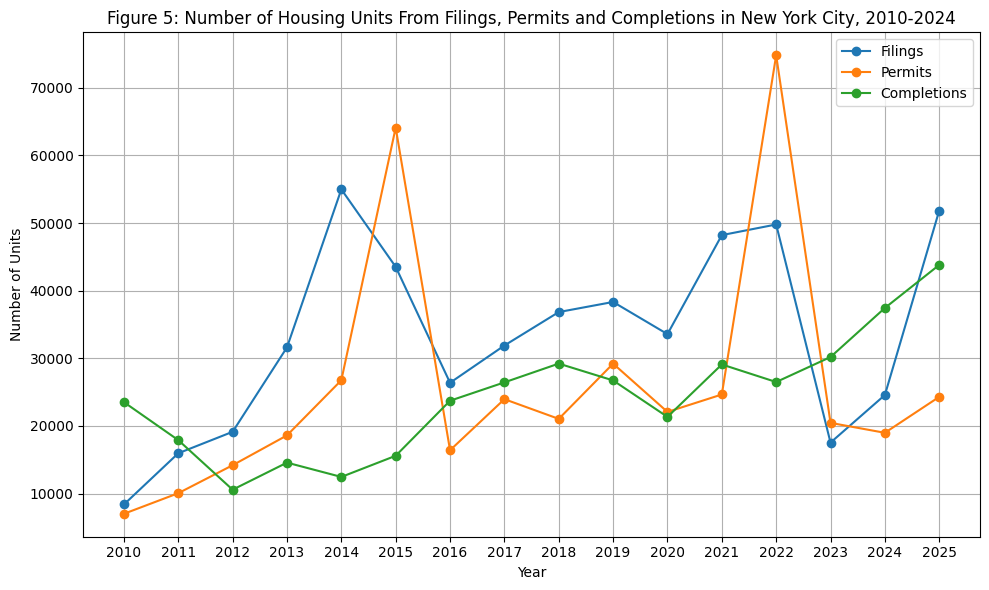

In [ ]:
#Now lets make a line graph of the data.
plt.figure(figsize=(10, 6))
plt.plot(pipeline_df.index, pipeline_df['Filings'], label='Filings', marker='o')
plt.plot(pipeline_df.index, pipeline_df['Permits'], label='Permits', marker='o')
plt.plot(pipeline_df.index, pipeline_df['Completions'], label='Completions', marker='o')
plt.title('Figure 5: Number of Housing Units From Filings, Permits and Completions in New York City, 2010-2024')
plt.xlabel('Year')
plt.ylabel('Number of Units')
plt.xticks(pipeline_df.index)  # Set x-ticks to be the years
plt.legend()
plt.grid(True)  # Add grid lines for better readability
plt.tight_layout()  # Adjust layout to prevent clipping of tick-labels
plt.show()  # Show the plot

The variation is even more intense for the filing and permits per year! Its worth noting the very low activity at the start of the period in 2010, which was in the aftermath of the Great Recession, which especially impacted the residential finance and construction sectors. The dramatic jumps in 2015 and 2022 in permits are very strongly correlated to the two expirations of the tax-incentive program 421-a, which expired in December 2015, was revived, and expired again in June 2022. These spikes should not be understood as single year events, as they represent an increase in a pipeline of projects that were already in the works and take different amounts of time to complete.

##### What is the Pipeline Now?
But how to do we understand the pipeline as something that projects are moving through? The first was is as a single cut at the end of the data, taking the statuses of the projects at their face value. However, its important to make sure that inactive projects (those that have not been updated in the previous 3 years) are excluded from this count. While those inactive projects may be revived, its useful to exclude them to reduce bloat of the figures from administrative oversights by project applicants.

In [ ]:
#This next section of code will set up a status over time dataframe for the projects in the dataset.
#This will be used to create a stacked line area chart for the status of the whole housing pipeline over time.

#First I will write out the working logic I made in excel to create the status in each year:
#=IF(AND([@Job_Status]]="9. Withdrawn",[@DateLstUpd]<DATEVALUE(S$1)), "Withdrawn",
#   IF(AND(YEAR([@DateLstUpd])<YEAR(DATEVALUE(S$1))-3),ISBLANK([@DateComplt])),
#       IF(ISBLANK([@DatePERMIT]), "Inactive Filed", "Inactive Permitted"),
#       IF(AND([@DateFiled]<DATEVALUE(S$1)), OR([@DatePermit]>= DATEVALUE(S$1),ISBLANK([@DatePermit])), OR([@DateComplt]>=DATEVALUE(S$1),ISBLANK([@DateComplt]))), "FILED",
#       IF(AND([@DatePermit]<DATEVALUE(S$1), NOT(ISBLANK([@DatePermit])), OR([@DateComplt]>=DATEVALUE(S$1),ISBLANK([@DateComplt]))), "PERMITTED",
#       IF(AND([@DateComplt]<DATEVALUE(S$1), NOT(ISBLANK([@DateComplt]))), "COMPLETED",
#       IF([@DateFiled]<DATEVALUE(S$1) "ERROR", "NOT FILED YET"))))))

#This worked by having a column header with the date of the first of each year (which is why "S$1" is called, as the formula would be copied down the column but pasted across the rows).

#First I will need to create a new column in the prDB dataset that will represent the status of the project in each year.

YearStatus = '01-01-2010' #Set the year to start at 2010.
YearStatus = pd.to_datetime(YearStatus) #Convert the year to a datetime object.

#Create a new column in the prDB dataset that will represent the status of the project in each year.
# Use a loop to dynamically create and update the status columns for each year
for year in range(2010, int(max_year) + 1):  # Will adjust the range as needed, in future might create a function to set the last year based on the vintage of the data.
    YearStatus = YearStatus.replace(year=year)  # Update the year in the datetime object to match the stage in the recursion loop.
    column_name = f'Status{year}' # Dynamically name the status column
    prDB[column_name] = 'Not Filed Yet'  # Set the default value for the column and create it within the prDB dataset, this will let us reference the project's other characteristics easily.
    prDB.loc[(prDB['Job_Status'] == '9. Withdrawn') & (prDB['DateLstUpd'] < YearStatus.replace(year=year)), column_name] = 'Withdrawn'  # Set the value to Withdrawn for the year when the Job_Status is '9. Withdrawn' and the DateLstUpd is less than the year.
    prDB.loc[(prDB[column_name] != 'Withdrawn') & (prDB['DateLstUpd'].dt.year < year - 3) & (prDB['DateComplt'].isnull()) & (prDB['DatePermit'].isnull()), column_name] = 'Inactive Filed'  # Set the value to Inactive Filed for the year when the DateLstUpd is less than the year - 3, the DateComplt is null, and the DatePermit is null, but only if the status is not already Withdrawn.
    prDB.loc[(prDB[column_name] != 'Withdrawn') & (prDB[column_name] != 'Inactive Filed') & (prDB['DateLstUpd'].dt.year < year - 3) & (prDB['DateComplt'].isnull()) & (prDB['DatePermit'].notnull()), column_name] = 'Inactive Permitted'  # Set the value to Inactive Permitted for the year when the DateComplt is null and the DatePERMIT is not null.
    prDB.loc[(prDB[column_name] != 'Withdrawn') & (prDB[column_name] != 'Inactive Filed') & (prDB[column_name] != 'Inactive Permitted') & (prDB['DateFiled'].dt.year < YearStatus.year) & ((prDB['DatePermit'].isnull()) | (prDB['DatePermit'] >= YearStatus)) & ((prDB['DateComplt'] >= YearStatus) | (prDB['DateComplt'].isnull())), column_name] = 'Filed'  # Set the value to Filed for the year when the DateFiled is less than the year and the DatePERMIT is not null and the DatePERMIT is greater than or equal to the year.
    prDB.loc[(prDB[column_name] != 'Withdrawn') & (prDB[column_name] != 'Inactive Filed') & (prDB[column_name] != 'Inactive Permitted') & (prDB['DatePermit'].dt.year < YearStatus.year) & (prDB['DatePermit'].notnull()) & ((prDB['DateComplt'] >= YearStatus) | (prDB['DateComplt'].isnull())), column_name] = 'Permitted'  # Set the value to Permitted for the year when the DatePERMIT is less than the year and the DateComplt is null.
    prDB.loc[(prDB[column_name] != 'Withdrawn') & (prDB[column_name] != 'Inactive Filed') & (prDB[column_name] != 'Inactive Permitted') & (prDB['DateComplt'].dt.year < YearStatus.year) & (prDB['DateComplt'].notnull()), column_name] = 'Completed'  # Set the value to Completed for the year when the DateComplt is less than the year and the DateComplt is not null.


In [ ]:
if vintage_type == 'Q2':
    # Define the column name as Status'Vintage' as requested
    column_name = f'Status{vintage}' # This will be 'Status2025_Q2' based on current vintage

    # Define the reference date for this specific vintage's status calculation
    # For a 'Q2' vintage, the status is typically evaluated as of the end of Q2.
    # The end_date_str variable is already defined as '2025-07-01', which aligns with this.
    status_as_of_date = pd.to_datetime(end_date_str)

    prDB[column_name] = 'Not Filed Yet'  # Initialize the new column with a default value

    # Apply the status logic, using status_as_of_date for all date comparisons
    # and status_as_of_date.year for year comparisons where needed.

    # 1. Withdrawn projects
    prDB.loc[(prDB['Job_Status'] == '9. Withdrawn') & (prDB['DateLstUpd'] < status_as_of_date), column_name] = 'Withdrawn'

    # 2. Inactive Filed projects (not Withdrawn, Last Updated more than 3 years ago, no completion, no permit)
    prDB.loc[(prDB[column_name] != 'Withdrawn') &
             (prDB['DateLstUpd'].dt.year < status_as_of_date.year - 3) &
             (prDB['DateComplt'].isnull()) &
             (prDB['DatePermit'].isnull()),
             column_name] = 'Inactive Filed'

    # 3. Inactive Permitted projects (not Withdrawn or Inactive Filed, Last Updated more than 3 years ago, no completion, has permit)
    prDB.loc[(prDB[column_name] != 'Withdrawn') &
             (prDB[column_name] != 'Inactive Filed') &
             (prDB['DateLstUpd'].dt.year < status_as_of_date.year - 3) &
             (prDB['DateComplt'].isnull()) &
             (prDB['DatePermit'].notnull()),
             column_name] = 'Inactive Permitted'

    # 4. Filed projects (not Withdrawn, Inactive, Filed before status_as_of_date, Permit is null OR after status_as_of_date, Completion is null OR after status_as_of_date)
    prDB.loc[(prDB[column_name] != 'Withdrawn') &
             (prDB[column_name] != 'Inactive Filed') &
             (prDB[column_name] != 'Inactive Permitted') &
             (prDB['DateFiled'] < status_as_of_date) &
             ((prDB['DatePermit'].isnull()) | (prDB['DatePermit'] >= status_as_of_date)) &
             ((prDB['DateComplt'].isnull()) | (prDB['DateComplt'] >= status_as_of_date)),
             column_name] = 'Filed'

    # 5. Permitted projects (not Withdrawn, Inactive, Permit before status_as_of_date, Permit is not null, Completion is null OR after status_as_of_date)
    prDB.loc[(prDB[column_name] != 'Withdrawn') &
             (prDB[column_name] != 'Inactive Filed') &
             (prDB[column_name] != 'Inactive Permitted') &
             (prDB['DatePermit'] < status_as_of_date) &
             (prDB['DatePermit'].notnull()) &
             ((prDB['DateComplt'].isnull()) | (prDB['DateComplt'] >= status_as_of_date)),
             column_name] = 'Permitted'

    # 6. Completed projects (not Withdrawn, Inactive, Completion before status_as_of_date, Completion is not null)
    prDB.loc[(prDB[column_name] != 'Withdrawn') &
             (prDB[column_name] != 'Inactive Filed') &
             (prDB[column_name] != 'Inactive Permitted') &
             (prDB['DateComplt'] < status_as_of_date) &
             (prDB['DateComplt'].notnull()),
             column_name] = 'Completed'

In [ ]:
print(prDB.head())

   Job_Number      Job_Type                 Job_Status  CompltYear  \
1   500525345  New Building  5. Completed Construction        2024   
2   500525381  New Building  5. Completed Construction        2017   
10  500550931  New Building  5. Completed Construction        2010   
11  500550940  New Building  5. Completed Construction        2010   
13  500553849  New Building  5. Completed Construction        2011   

    PermitYear  ClassAInit  ClassAProp  ClassANet           Boro         BBL  \
1         2002           0           1          1  Staten Island  5034020006   
2         2002           0           2          2  Staten Island  5011400061   
10        <NA>           0           1          1  Staten Island  5006600018   
11        <NA>           0           1          1  Staten Island  5006600019   
13        2003           0           1          1  Staten Island  5069760001   

    ... Status2016 Status2017 Status2018 Status2019 Status2020 Status2021  \
1   ...  Permitted  P

In [ ]:
#Check the head of the dataset to see if this worked.
print(prDB.head(5)) #Check the head of the dataset.
#Check the number of nulls in the dataset again.
print("The number of null values in the dataset:", prDB.isnull().sum()) #Check for null values.



   Job_Number      Job_Type                 Job_Status  CompltYear  \
1   500525345  New Building  5. Completed Construction        2024   
2   500525381  New Building  5. Completed Construction        2017   
10  500550931  New Building  5. Completed Construction        2010   
11  500550940  New Building  5. Completed Construction        2010   
13  500553849  New Building  5. Completed Construction        2011   

    PermitYear  ClassAInit  ClassAProp  ClassANet           Boro         BBL  \
1         2002           0           1          1  Staten Island  5034020006   
2         2002           0           2          2  Staten Island  5011400061   
10        <NA>           0           1          1  Staten Island  5006600018   
11        <NA>           0           1          1  Staten Island  5006600019   
13        2003           0           1          1  Staten Island  5069760001   

    ... Status2016 Status2017 Status2018 Status2019 Status2020 Status2021  \
1   ...  Permitted  P

In [ ]:
# Create a list of all dynamically generated 'StatusYear' columns
status_columns = [col for col in prDB.columns if col.startswith('Status')]

# Initialize an empty dictionary to store the aggregated data
aggregated_data = {}

# Iterate over each status column and perform the groupby and sum operation
for status_col in status_columns:
    # Group by 'Boro' and the current 'Status' column, then sum 'ClassANet'
    # The .unstack(fill_value=0) will pivot the status categories into columns
    # and fill any missing combinations with 0.
    yearly_status_summary = prDB.groupby(['Boro', status_col], observed=False)['ClassANet'].sum().unstack(fill_value=0)

    # Store the result in the dictionary, keyed by the status column name
    aggregated_data[status_col] = yearly_status_summary

# Combine all yearly status summaries into a single DataFrame if needed,
# or process them individually. For now, let's create a multi-indexed DataFrame.

# To get a cleaner DataFrame where each row is a Boro and columns are StatusYear_StatusCategory
StatusYearBoroSummary = pd.DataFrame(index=prDB['Boro'].unique())

for status_col, df in aggregated_data.items():
    for status_category in df.columns:
        column_name = f'{status_col}_{status_category}'
        StatusYearBoroSummary[column_name] = df[status_category]

StatusYearBoroSummary = StatusYearBoroSummary.fillna(0).astype(int)

# Display the head of the summary DataFrame
#print(StatusYearBoroSummary.head())


In [ ]:
# Create a list of all dynamically generated 'StatusYear' columns
status_columns = [col for col in prDB.columns if col.startswith('Status')]

# Initialize an empty dictionary to store the aggregated data
aggregated_data = {}

# Iterate over each status column and perform the groupby and sum operation
for status_col in status_columns:
    # Group by 'PUMA' and the current 'Status' column, then sum 'ClassANet'
    # The .unstack(fill_value=0) will pivot the status categories into columns
    # and fill any missing combinations with 0.
    yearly_status_summary = prDB.groupby(['PUMA', status_col], observed=False)['ClassANet'].sum().unstack(fill_value=0)

    # Store the result in the dictionary, keyed by the status column name
    aggregated_data[status_col] = yearly_status_summary

# Combine all yearly status summaries into a single DataFrame if needed,
# or process them individually. For now, let's create a multi-indexed DataFrame.

# To get a cleaner DataFrame where each row is a PUMA and columns are StatusYear_StatusCategory
StatusYearPUMASummary = pd.DataFrame(index=prDB['PUMA'].unique())

for status_col, df in aggregated_data.items():
    for status_category in df.columns:
        column_name = f'{status_col}_{status_category}'
        StatusYearPUMASummary[column_name] = df[status_category]

StatusYearPUMASummary = StatusYearPUMASummary.fillna(0).astype(int)

# Display the head of the summary DataFrame
#print(StatusYearPUMASummary.head())


In [ ]:
# Create a list of all dynamically generated 'StatusYear' columns
status_columns = [col for col in prDB.columns if col.startswith('Status')]

# Initialize an empty dictionary to store the aggregated data
aggregated_data = {}

# Iterate over each status column and perform the groupby and sum operation
for status_col in status_columns:
    # Group by 'NTA' and the current 'Status' column, then sum 'ClassANet'
    # The .unstack(fill_value=0) will pivot the status categories into columns
    # and fill any missing combinations with 0.
    yearly_status_summary = prDB.groupby(['NTA2020', status_col], observed=False)['ClassANet'].sum().unstack(fill_value=0)

    # Store the result in the dictionary, keyed by the status column name
    aggregated_data[status_col] = yearly_status_summary

# Combine all yearly status summaries into a single DataFrame if needed,
# or process them individually. For now, let's create a multi-indexed DataFrame.

# To get a cleaner DataFrame where each row is a NTA and columns are StatusYear_StatusCategory
StatusYearNTASummary = pd.DataFrame(index=prDB['NTA2020'].unique())

for status_col, df in aggregated_data.items():
    for status_category in df.columns:
        column_name = f'{status_col}_{status_category}'
        StatusYearNTASummary[column_name] = df[status_category]

StatusYearNTASummary = StatusYearNTASummary.fillna(0).astype(int)

# Display the head of the summary DataFrame
#print(StatusYearNTASummary.head())

In [ ]:
# Initialize vis1_boro from StockBoro
vis1_boro = StockBoro.copy()
vis1_boro = vis1_boro.reset_index()

# Rename the last stock column to 'Number of Units, {max_year}{vintage_type}' using the dynamically determined name
vis1_boro = vis1_boro.rename(columns={stockBorolastcolumn: f'Number of Units, {max_year_int}{vintage_type}'})

#Grab the YearStatus for the current vintage by borough for the table.
CurrentPipelineStatus = pd.crosstab(prDB['Boro'],prDB[f'Status{year}'], values=prDB['ClassANet'], aggfunc='sum', margins=True, margins_name='New York City') #Crosstabing the data to get the number of units in projects by borough and status.

# Reset index to make 'Boro' a column
CurrentPipelineStatus = CurrentPipelineStatus.reset_index()

#Lets only keep Filed and Permitted, and 'Boro' column for mapping
CurrentPipelineStatus = CurrentPipelineStatus[['Boro', 'Filed','Permitted']]

# Get the total number of units for New York City from vis1_boro sum
nyc_total_units_column_name = f'Number of Units, {max_year_int}{vintage_type}'
nyc_total_units = vis1_boro[nyc_total_units_column_name].sum()

# Add the total units column to CurrentPipelineStatus for all rows (including the 'New York City' row)
CurrentPipelineStatus[nyc_total_units_column_name] = CurrentPipelineStatus['Boro'].map(vis1_boro.set_index('Boro')[nyc_total_units_column_name])
# Fill the 'New York City' row's total units with the calculated sum
CurrentPipelineStatus.loc[CurrentPipelineStatus['Boro'] == 'New York City', nyc_total_units_column_name] = nyc_total_units

#Now I will create a new column that will divide permitted by the Number of Units, {max_year}{vintage_type} to get the Permitted as % of Stock.
CurrentPipelineStatus['Permitted as % of Stock'] = CurrentPipelineStatus['Permitted'] / CurrentPipelineStatus[nyc_total_units_column_name] * 100
CurrentPipelineStatus['Permitted as % of Stock'] = CurrentPipelineStatus['Permitted as % of Stock'].round(2) #Round the values to 2 decimal places.
CurrentPipelineStatus['Permitted as % of Stock'] = CurrentPipelineStatus['Permitted as % of Stock'].astype(str) + '%'

#Then cut 'Number of Units, {max_year}{vintage_type}' as I don't  need it anymore.
CurrentPipelineStatus = CurrentPipelineStatus.drop(columns=[nyc_total_units_column_name]) #Drop the column.

print(CurrentPipelineStatus) #Check the crosstab with updated index.


Status2025           Boro  Filed  Permitted Permitted as % of Stock
0               Manhattan  12371      18070                   1.92%
1                   Bronx  12471      16013                   2.74%
2                Brooklyn  13015      44027                   3.83%
3                  Queens  12084      22173                   2.36%
4           Staten Island   3011       1049                   0.56%
5           New York City  52952     101332                   2.66%


Brooklyn both as many more permitted units both in quantity (double other boroughs) and as a share of the total housing stock, indicating that many more units will be produced in Brooklyn relative to other boroughs over time, as had often been the case historically.

##### Shape of the Pipeline over Time

In [ ]:
#This will be a stacked area chart with the project statuses as the slices and the number of units present as the size of the slices.
#I will create a new dataframe that will have the project statuses as the index and the years as the columns, I will conver the status names to dates to make it easier to work with in a graph.

pipelineovertime = pd.DataFrame(index=prDB['Status2025'].unique(), columns=range(2010, 2025)) #Create a new dataframe with the project statuses as the index and the years as the columns.
#By using the last year's statuses, we also depricate 'Not Filed Yet' and 'Error' as they are not present in the 2025 status.

#Populate the dataframe with the number of units for each status and year.



#print(pipelineovertime.head(5)) #Check the head of the dataset.

# Populate the dataframe with the number of units for each status and year
for year in range(2010, 2026):
    column_name = f'Status{year}'
    pipelineovertime[year] = prDB.groupby(column_name)['ClassANet'].sum()

# Reset the index to make it easier to work with in a graph
pipelineovertime = pipelineovertime.reset_index()

#Replace all NA values with 0
pipelineovertime = pipelineovertime.fillna(0) #Replace all NA values with 0.

#Sum the Inactive Filed and Inactive Permitted into one row called Inactive.
pipelineovertime.loc[pipelineovertime['index'] == 'Inactive Filed', range(2010, 2025)] += pipelineovertime.loc[pipelineovertime['index'] == 'Inactive Permitted', range(2010, 2025)].values
pipelineovertime = pipelineovertime[pipelineovertime['index'] != 'Inactive Permitted']
pipelineovertime.loc[pipelineovertime['index'] == 'Inactive Filed', 'index'] = 'Inactive'


#Transpose the dataframe to make it easier to work with in a graph.
pipelineovertime = pipelineovertime.set_index('index').T  # Transpose the dataframe to have years as the index and statuses as the columns.
pipelineovertime = pipelineovertime.rename_axis('Year') # Rename the index to Year and reset the index to make it easier to work with in a graph.
pipelineovertime = pipelineovertime.reset_index() # Reset the index to make it easier to work with in a graph.


#print(pipelineovertime)  # Check the head of the dataset
#print(pipelineovertime.dtypes)  # Check the columns of the dataset

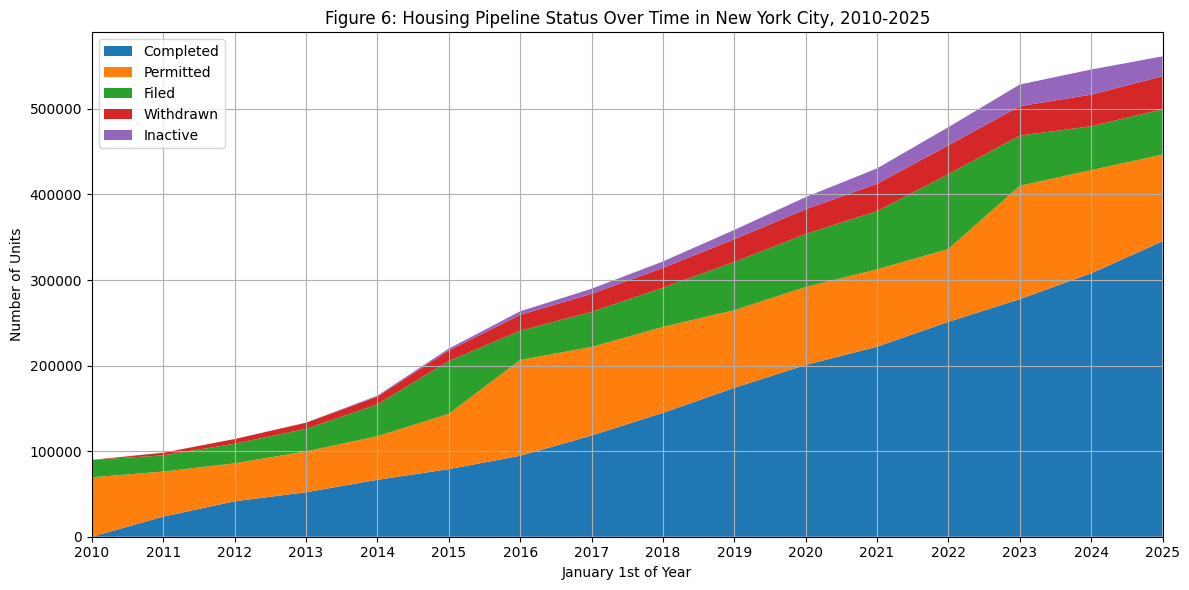

In [ ]:
#Now we combine the pipelineovertime into a stacked area chart.
plt.figure(figsize=(12, 6))  # Set the figure size
plt.stackplot(pipelineovertime['Year'], pipelineovertime['Completed'], pipelineovertime['Permitted'], pipelineovertime['Filed'], pipelineovertime['Withdrawn'], pipelineovertime['Inactive'], labels=['Completed','Permitted','Filed','Withdrawn','Inactive'])  # Create the stacked area chart
plt.title('Figure 6: Housing Pipeline Status Over Time in New York City, 2010-2025')  # Set the title
plt.xlabel('January 1st of Year')  # Set the x-axis label
plt.ylabel('Number of Units')  # Set the y-axis label
plt.xticks(pipelineovertime['Year'])  # Set x-ticks to be the years
plt.xlim(pipelineovertime['Year'].min(), pipelineovertime['Year'].max())  # Set x-axis limits to the range of years
plt.legend(loc='upper left')  # Add a legend to the chart
plt.grid(True)  # Add grid lines for better readability
plt.tight_layout()  # Adjust layout to prevent clipping of tick-labels
plt.show()  # Show the plot



####Housing Pipeline Print

In [ ]:
with pd.ExcelWriter(f'HousingPipeline{vintage}.xlsx', engine='xlsxwriter') as writer:
    # Write each DataFrame to a separate sheet
    CurrentPipelineStatus.to_excel(writer, sheet_name='CurrentPipelineStatus', index=True)
    StatusYearPUMASummary.to_excel(writer, sheet_name='StatusYearPUMASummary', index=True)
    StatusYearBoroSummary.to_excel(writer, sheet_name='StatusYearBoroSummary', index=True)
    StatusYearNTASummary.to_excel(writer, sheet_name='StatusYearNTASummary', index=True)
    prDB.to_excel(writer, sheet_name='prDB', index=True)
files.download(f'HousingPipeline{vintage}.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>